#ბიბლიოთეკების დაყენება

In [1]:
!pip install -q kaggle mlflow dagshub neuralforecast statsforecast datasetsforecast

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 1.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 83.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 95.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 43.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.3/273.3 kB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.0/302.0 kB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 501.0/501.0 kB 28.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.6/348.6 kB 25.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 80.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6

#Kaggle API Key-ის ატვირთვა

In [2]:
from google.colab import files

files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"lukakharbedia","key":"bb99fe3abee853ef6d46f427d7ce0d90"}'}

#kaggle.json-ის სწორ ადგილას გადატანა

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

#Dataset-ის ჩამოტვირთვა

In [4]:
!kaggle competitions download -c walmart-recruiting-store-sales-forecasting

100% 2.70M/2.70M [00:00<00:00, 145MB/s]



#ZIP ფაილების გახსნა

In [5]:
!unzip -o walmart-recruiting-store-sales-forecasting.zip
!unzip -o train.csv.zip
!unzip -o test.csv.zip
!unzip -o features.csv.zip

Archive:  walmart-recruiting-store-sales-forecasting.zip
  inflating: features.csv.zip        
  inflating: sampleSubmission.csv.zip  
  inflating: stores.csv              
  inflating: test.csv.zip            
  inflating: train.csv.zip           
Archive:  train.csv.zip
  inflating: train.csv               
Archive:  test.csv.zip
  inflating: test.csv                
Archive:  features.csv.zip
  inflating: features.csv            


#შემოწმება

In [6]:
import os

os.listdir()

['.config',
 'test.csv',
 'kaggle.json',
 'test.csv.zip',
 'stores.csv',
 'sampleSubmission.csv.zip',
 'train.csv',
 'train.csv.zip',
 'walmart-recruiting-store-sales-forecasting.zip',
 'features.csv',
 'features.csv.zip',
 'sample_data']

#Dagshub და mlflow გამართვა

In [7]:
import dagshub
import mlflow

dagshub.init(
    repo_owner="tsarc21",
    repo_name="Walmart-Recruiting---Store-Sales-Forecasting",
    mlflow=True
)

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=4493ba6e-cbac-4bb7-9872-1e59edaaa368&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=b054a760baa2fb40279b7c3fbb3616522bf68d00f4001cea73cc0dc794f29cd0




Accessing as lkhar21

Initialized MLflow to track repo "tsarc21/Walmart-Recruiting---Store-Sales-Forecasting"

Repository tsarc21/Walmart-Recruiting---Store-Sales-Forecasting initialized!

In [8]:
import mlflow

print(mlflow.get_tracking_uri())

https://dagshub.com/tsarc21/Walmart-Recruiting---Store-Sales-Forecasting.mlflow


In [9]:
import os

for root, dirs, files in os.walk("/content"):
    for file in files:
        if file.endswith((".csv", ".zip")):
            print(os.path.join(root, file))

/content/test.csv
/content/test.csv.zip
/content/stores.csv
/content/sampleSubmission.csv.zip
/content/train.csv
/content/train.csv.zip
/content/walmart-recruiting-store-sales-forecasting.zip
/content/features.csv
/content/features.csv.zip
/content/sample_data/california_housing_test.csv
/content/sample_data/mnist_train_small.csv
/content/sample_data/california_housing_train.csv
/content/sample_data/mnist_test.csv


In [10]:
import pandas as pd

train = pd.read_csv("/content/train.csv")
test = pd.read_csv("/content/test.csv")
features = pd.read_csv("/content/features.csv")
stores = pd.read_csv("/content/stores.csv")

print("train:", train.shape)
print("test:", test.shape)
print("features:", features.shape)
print("stores:", stores.shape)

display(train.head())
display(test.head())
display(features.head())
display(stores.head())

train: (421570, 5)
test: (115064, 4)
features: (8190, 12)
stores: (45, 3)


,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


,Store,Dept,Date,IsHoliday
0,1,1,2012-11-02,False
1,1,1,2012-11-09,False
2,1,1,2012-11-16,False
3,1,1,2012-11-23,True
4,1,1,2012-11-30,False


,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,2010-02-26,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,2010-03-05,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875


In [11]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [12]:
import os
import shutil

PROJECT_PATH = "/content/drive/MyDrive/ML-store-sales-forecast"
DATA_PATH = f"{PROJECT_PATH}/data"

os.makedirs(DATA_PATH, exist_ok=True)

files_to_copy = [
    "/content/train.csv",
    "/content/test.csv",
    "/content/features.csv",
    "/content/stores.csv"
]

for file_path in files_to_copy:
    shutil.copy(file_path, DATA_PATH)

print("CSV files saved to:", DATA_PATH)
print(os.listdir(DATA_PATH))

CSV files saved to: /content/drive/MyDrive/ML-store-sales-forecast/data
['train.csv', 'stores.csv', 'features.csv', 'test.csv']


In [13]:
import pandas as pd

DATA_PATH = "/content/drive/MyDrive/ML-store-sales-forecast/data"

train = pd.read_csv(f"{DATA_PATH}/train.csv")
test = pd.read_csv(f"{DATA_PATH}/test.csv")
features = pd.read_csv(f"{DATA_PATH}/features.csv")
stores = pd.read_csv(f"{DATA_PATH}/stores.csv")

print(train.shape, test.shape, features.shape, stores.shape)

(421570, 5) (115064, 4) (8190, 12) (45, 3)


In [14]:
import pandas as pd

train = pd.read_csv("/content/train.csv")
test = pd.read_csv("/content/test.csv")
features = pd.read_csv("/content/features.csv")
stores = pd.read_csv("/content/stores.csv")

print(train.shape)
print(test.shape)
print(features.shape)
print(stores.shape)

(421570, 5)
(115064, 4)
(8190, 12)
(45, 3)


#N-BEATS-ისთვის მონაცემების გაერთიანება (merge).

ეს აუცილებელია, რადგან N-BEATS-შიც გვჭირდება IsHoliday და ზოგიერთ ანალიზში Type, Size და სხვა ინფორმაცია.

In [15]:
train_full = train.merge(
    features,
    on=["Store", "Date", "IsHoliday"],
    how="left"
)

train_full = train_full.merge(
    stores,
    on="Store",
    how="left"
)

test_full = test.merge(
    features,
    on=["Store", "Date", "IsHoliday"],
    how="left"
)

test_full = test_full.merge(
    stores,
    on="Store",
    how="left"
)

print(train_full.shape)
print(test_full.shape)

display(train_full.head())

(421570, 16)
(115064, 15)


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315


In [16]:
# თარიღების datetime ტიპში გადაყვანა
train["Date"] = pd.to_datetime(train["Date"])
test["Date"] = pd.to_datetime(test["Date"])
features["Date"] = pd.to_datetime(features["Date"])

# Train-ის გაერთიანება დამატებით მონაცემებთან
train_full = train.merge(
    features,
    on=["Store", "Date", "IsHoliday"],
    how="left"
)

train_full = train_full.merge(
    stores,
    on="Store",
    how="left"
)

# Test-ის გაერთიანება დამატებით მონაცემებთან
test_full = test.merge(
    features,
    on=["Store", "Date", "IsHoliday"],
    how="left"
)

test_full = test_full.merge(
    stores,
    on="Store",
    how="left"
)

print("Train shape before merge:", train.shape)
print("Train shape after merge:", train_full.shape)

print("Test shape before merge:", test.shape)
print("Test shape after merge:", test_full.shape)

display(train_full.head())

Train shape before merge: (421570, 5)
Train shape after merge: (421570, 16)
Test shape before merge: (115064, 4)
Test shape after merge: (115064, 15)


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315


In [17]:
# 1. ძირითადი ინფორმაცია
print("Train shape:", train_full.shape)
print("\nData types:")
print(train_full.dtypes)

# 2. NaN მნიშვნელობების რაოდენობა და პროცენტი
nan_summary = pd.DataFrame({
    "NaN_count": train_full.isna().sum(),
    "NaN_percent": (train_full.isna().mean() * 100).round(2)
}).sort_values("NaN_percent", ascending=False)

print("\nNaN summary:")
display(nan_summary)

# 3. დუბლირებული Store-Dept-Date ჩანაწერები
duplicate_count = train_full.duplicated(
    subset=["Store", "Dept", "Date"]
).sum()

print("Duplicate Store-Dept-Date rows:", duplicate_count)

# 4. Weekly_Sales-ის პრობლემური მნიშვნელობები
print("Weekly_Sales NaN:", train_full["Weekly_Sales"].isna().sum())
print("Negative Weekly_Sales:", (train_full["Weekly_Sales"] < 0).sum())
print("Zero Weekly_Sales:", (train_full["Weekly_Sales"] == 0).sum())

# 5. გაყიდვების სტატისტიკა
print("\nWeekly_Sales statistics:")
display(train_full["Weekly_Sales"].describe())

# 6. უნიკალური სერიების რაოდენობა
series_count = train_full[["Store", "Dept"]].drop_duplicates().shape[0]

print("Unique Store-Dept series:", series_count)

Train shape: (421570, 16)

Data types:
Store                    int64
Dept                     int64
Date            datetime64[ns]
Weekly_Sales           float64
IsHoliday                 bool
Temperature            float64
Fuel_Price             float64
MarkDown1              float64
MarkDown2              float64
MarkDown3              float64
MarkDown4              float64
MarkDown5              float64
CPI                    float64
Unemployment           float64
Type                    object
Size                     int64
dtype: object

NaN summary:


,NaN_count,NaN_percent
MarkDown2,310322,73.61
MarkDown4,286603,67.98
MarkDown3,284479,67.48
MarkDown1,270889,64.26
MarkDown5,270138,64.08
Store,0,0.00
Date,0,0.00
Dept,0,0.00
Fuel_Price,0,0.00
Temperature,0,0.00


Duplicate Store-Dept-Date rows: 0
Weekly_Sales NaN: 0
Negative Weekly_Sales: 1285
Zero Weekly_Sales: 73

Weekly_Sales statistics:


,Weekly_Sales
count,421570.000000
mean,15981.258123
std,22711.183519
min,-4988.940000
25%,2079.650000
50%,7612.030000
75%,20205.852500
max,693099.360000


Unique Store-Dept series: 3331


In [18]:
# N-BEATS-ისთვის საჭირო ფორმატი

nbeats_df = train_full.copy()

# თითოეული Store-Dept გახდება ცალკე Time Series
nbeats_df["unique_id"] = (
    nbeats_df["Store"].astype(str)
    + "_"
    + nbeats_df["Dept"].astype(str)
)

# NeuralForecast-ის სტანდარტული სახელები
nbeats_df = nbeats_df.rename(columns={
    "Date": "ds",
    "Weekly_Sales": "y"
})

# ქრონოლოგიური დალაგება
nbeats_df = nbeats_df.sort_values(
    ["unique_id", "ds"]
).reset_index(drop=True)

display(
    nbeats_df[
        ["unique_id", "ds", "y", "IsHoliday"]
    ].head(15)
)

print("Total Series:", nbeats_df["unique_id"].nunique())

,unique_id,ds,y,IsHoliday
0,10_1,2010-02-05,40212.84,False
1,10_1,2010-02-12,67699.32,True
2,10_1,2010-02-19,49748.33,False
3,10_1,2010-02-26,33601.22,False
4,10_1,2010-03-05,36572.44,False
5,10_1,2010-03-12,36380.70,False
6,10_1,2010-03-19,38252.33,False
7,10_1,2010-03-26,51956.73,False
8,10_1,2010-04-02,131853.01,False
9,10_1,2010-04-09,89207.79,False


Total Series: 3331


#ერთი Store–Dept სერიის გაყიდვების გრაფიკი

ეს გრაფიკი აჩვენებს, რეალურად რას ხედავს N-BEATS — გაყიდვების ქრონოლოგიურ ისტორიას.

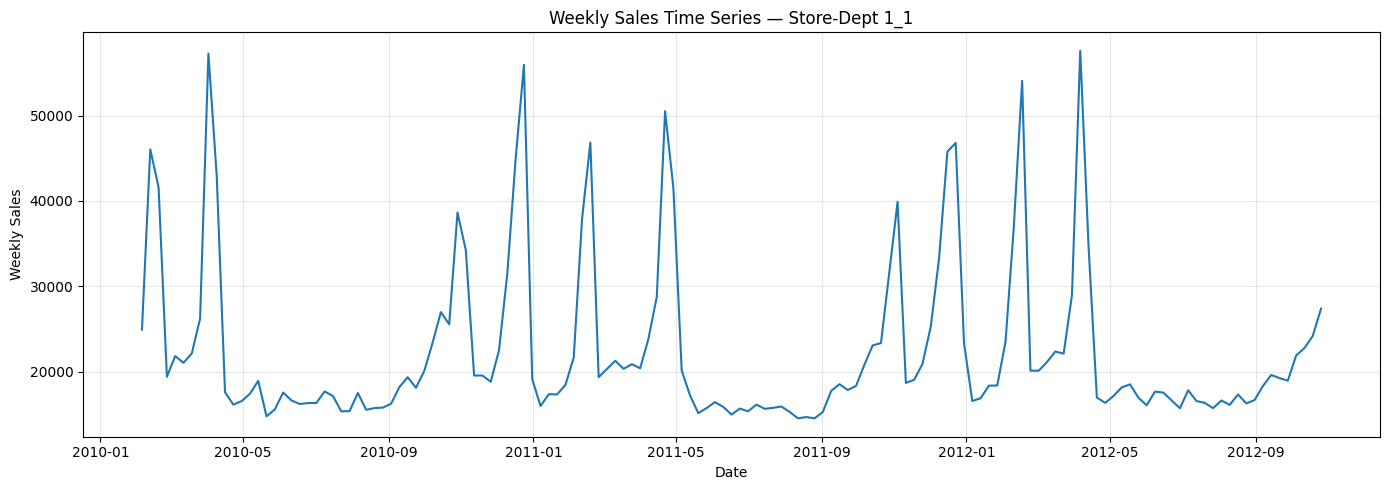

In [19]:
import matplotlib.pyplot as plt

sample_id = "1_1"

sample_series = nbeats_df[
    nbeats_df["unique_id"] == sample_id
].sort_values("ds")

plt.figure(figsize=(14, 5))
plt.plot(
    sample_series["ds"],
    sample_series["y"],
    linewidth=1.5
)

plt.title(f"Weekly Sales Time Series — Store-Dept {sample_id}")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#Holiday და ჩვეულებრივი კვირების გამოყოფა

აქ დღესასწაულის კვირებს ცალკე წერტილებით მოვნიშნავთ.

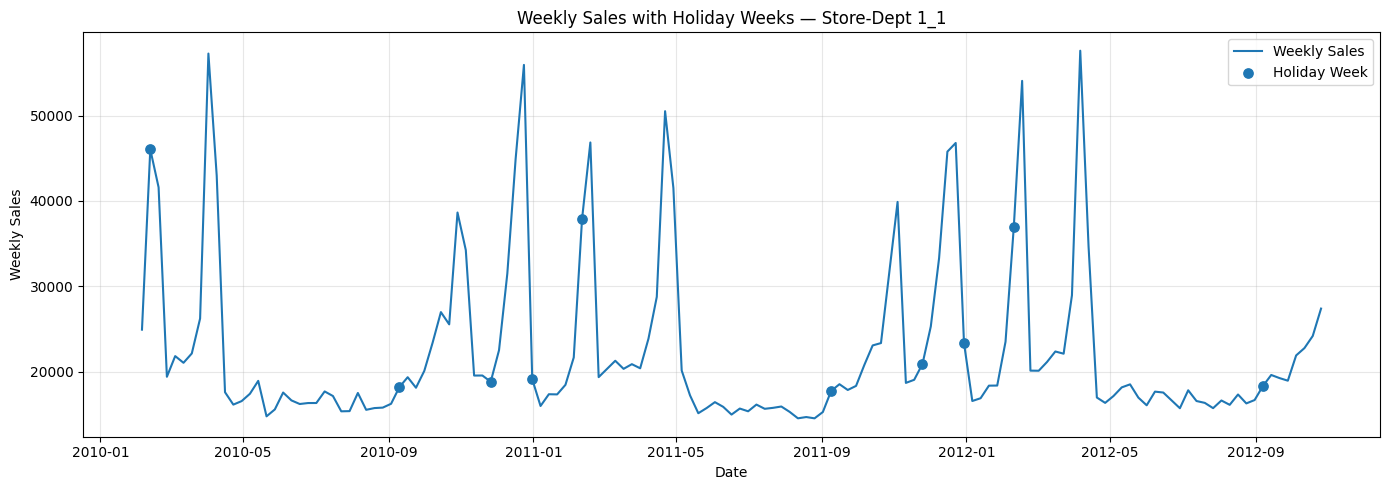

In [20]:
sample_holidays = sample_series[
    sample_series["IsHoliday"] == True
]

plt.figure(figsize=(14, 5))

plt.plot(
    sample_series["ds"],
    sample_series["y"],
    linewidth=1.5,
    label="Weekly Sales"
)

plt.scatter(
    sample_holidays["ds"],
    sample_holidays["y"],
    s=45,
    label="Holiday Week",
    zorder=3
)

plt.title(f"Weekly Sales with Holiday Weeks — Store-Dept {sample_id}")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#ყველა დროითი სერიის სიგრძის განაწილება

შემდეგ უნდა გავიგოთ, თითოეულ Store–Dept სერიას რამდენი კვირა აქვს.

count    3331.000000
mean      126.559592
std        40.212763
min         1.000000
25%       143.000000
50%       143.000000
75%       143.000000
max       143.000000
Name: weeks, dtype: float64


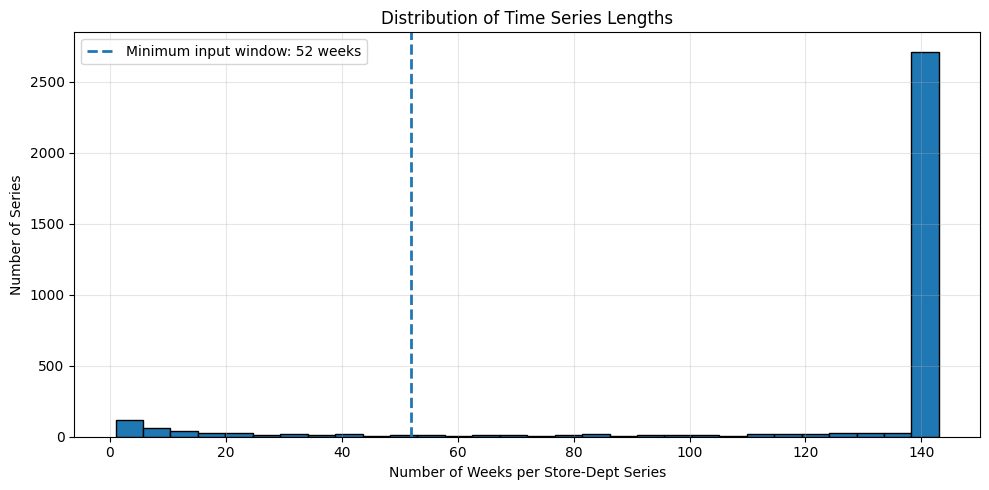

In [21]:
series_lengths = (
    nbeats_df
    .groupby("unique_id")
    .size()
    .rename("weeks")
)

print(series_lengths.describe())

plt.figure(figsize=(10, 5))
plt.hist(
    series_lengths,
    bins=30,
    edgecolor="black"
)

plt.axvline(
    52,
    linestyle="--",
    linewidth=2,
    label="Minimum input window: 52 weeks"
)

plt.title("Distribution of Time Series Lengths")
plt.xlabel("Number of Weeks per Store-Dept Series")
plt.ylabel("Number of Series")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

,0
Less than 52 weeks,340
52–91 weeks,96
92 or more weeks,2895


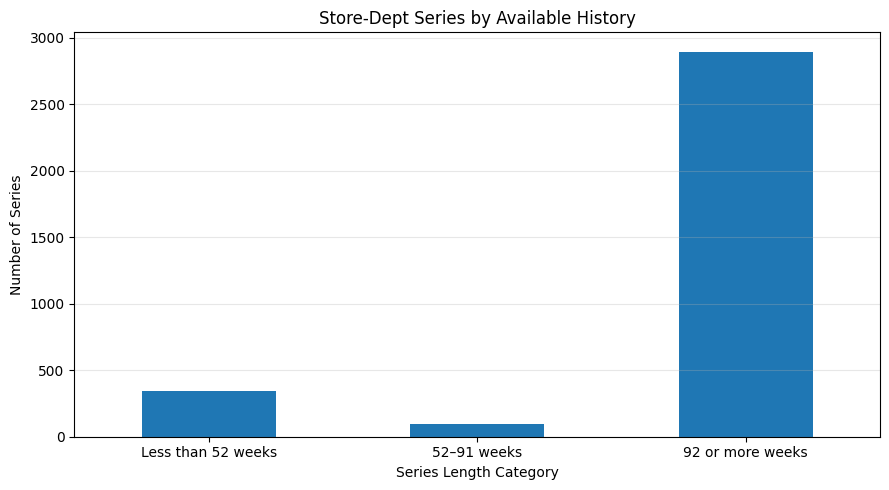

In [22]:
length_categories = pd.Series({
    "Less than 52 weeks": (series_lengths < 52).sum(),
    "52–91 weeks": (
        (series_lengths >= 52) &
        (series_lengths < 92)
    ).sum(),
    "92 or more weeks": (series_lengths >= 92).sum()
})

display(length_categories)

plt.figure(figsize=(9, 5))
length_categories.plot(kind="bar")

plt.title("Store-Dept Series by Available History")
plt.xlabel("Series Length Category")
plt.ylabel("Number of Series")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [23]:
series_lengths = (
    nbeats_df
    .groupby("unique_id")
    .size()
    .rename("weeks")
)

print("Series length statistics:")
display(series_lengths.describe())

length_categories = pd.Series({
    "Less than 52 weeks": (series_lengths < 52).sum(),
    "52–91 weeks": (
        (series_lengths >= 52) &
        (series_lengths < 92)
    ).sum(),
    "92 or more weeks": (series_lengths >= 92).sum()
})

print("\nSeries length categories:")
display(length_categories)

Series length statistics:


,weeks
count,3331.000000
mean,126.559592
std,40.212763
min,1.000000
25%,143.000000
50%,143.000000
75%,143.000000
max,143.000000



Series length categories:


,0
Less than 52 weeks,340
52–91 weeks,96
92 or more weeks,2895


#არასრული დროითი სერიების წაშლა რომელთაც 92 კვირაზე ნაკლები მონაცემები აქვთ

In [24]:
MIN_SERIES_LENGTH = 92

valid_ids = series_lengths[
    series_lengths >= MIN_SERIES_LENGTH
].index

nbeats_filtered = (
    nbeats_df[
        nbeats_df["unique_id"].isin(valid_ids)
    ]
    .copy()
    .sort_values(["unique_id", "ds"])
    .reset_index(drop=True)
)

print("Series before filtering:", nbeats_df["unique_id"].nunique())
print("Series after filtering:", nbeats_filtered["unique_id"].nunique())
print("Removed series:", nbeats_df["unique_id"].nunique() - nbeats_filtered["unique_id"].nunique())

print("\nRows before filtering:", len(nbeats_df))
print("Rows after filtering:", len(nbeats_filtered))

Series before filtering: 3331
Series after filtering: 2895
Removed series: 436

Rows before filtering: 421570
Rows after filtering: 409614


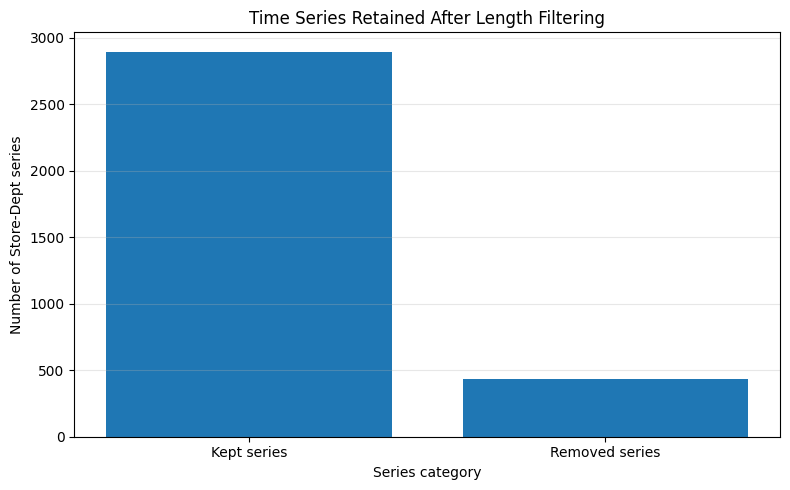

In [25]:
import matplotlib.pyplot as plt

filter_summary = {
    "Kept series": len(valid_ids),
    "Removed series": len(series_lengths) - len(valid_ids)
}

plt.figure(figsize=(8, 5))
plt.bar(
    filter_summary.keys(),
    filter_summary.values()
)

plt.title("Time Series Retained After Length Filtering")
plt.xlabel("Series category")
plt.ylabel("Number of Store-Dept series")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

#N-BEATS რიგით მნიშვნელობებზე მუშაობს. თუ კვირა აკლია, მოდელმა შეიძლება ჩათვალოს, რომ ორი მეზობელი ჩანაწერი ერთმანეთის მომდევნო კვირებია, რაც არასწორია.

In [26]:
weekly_gaps = nbeats_filtered[
    ["unique_id", "ds", "y"]
].copy()

weekly_gaps["days_since_previous"] = (
    weekly_gaps
    .groupby("unique_id")["ds"]
    .diff()
    .dt.days
)

gap_rows = weekly_gaps[
    weekly_gaps["days_since_previous"].notna()
    & (weekly_gaps["days_since_previous"] != 7)
]

print("Rows with non-weekly gaps:", len(gap_rows))
print(
    "Series containing gaps:",
    gap_rows["unique_id"].nunique()
)

display(gap_rows.head(20))

Rows with non-weekly gaps: 1862
Series containing gaps: 224


,unique_id,ds,y,days_since_previous
1158,10_18,2010-09-03,-17.00,119.0
1195,10_18,2011-05-27,-2.00,14.0
1197,10_18,2011-06-24,-4.00,21.0
1198,10_18,2011-08-12,-19.97,49.0
1199,10_18,2011-09-02,24.73,21.0
1237,10_18,2012-06-29,2.97,42.0
1239,10_18,2012-08-24,179.30,49.0
6030,10_54,2011-04-22,98.84,14.0
6056,10_54,2011-10-28,93.08,14.0
6094,10_54,2012-07-27,83.84,14.0


In [27]:
series_date_audit = (
    nbeats_filtered
    .groupby("unique_id")
    .agg(
        start_date=("ds", "min"),
        end_date=("ds", "max"),
        actual_weeks=("ds", "count")
    )
)

series_date_audit["expected_weeks"] = (
    (
        series_date_audit["end_date"]
        - series_date_audit["start_date"]
    ).dt.days // 7
) + 1

series_date_audit["missing_weeks"] = (
    series_date_audit["expected_weeks"]
    - series_date_audit["actual_weeks"]
)

print("Series with missing weeks:")
print((series_date_audit["missing_weeks"] > 0).sum())

print("\nTotal missing weeks:")
print(series_date_audit["missing_weeks"].clip(lower=0).sum())

display(
    series_date_audit[
        series_date_audit["missing_weeks"] > 0
    ].sort_values(
        "missing_weeks",
        ascending=False
    ).head(20)
)

Series with missing weeks:
224

Total missing weeks:
3982


,start_date,end_date,actual_weeks,expected_weeks,missing_weeks
unique_id,,,,,
17_18,2010-02-05,2012-10-26,92,143,51
23_94,2010-02-05,2012-10-19,92,142,50
30_56,2010-02-05,2012-10-26,93,143,50
35_94,2010-02-19,2012-10-26,92,141,49
7_18,2010-02-05,2012-10-26,95,143,48
43_18,2010-02-05,2012-10-26,96,143,47
15_94,2010-02-05,2012-10-26,96,143,47
16_18,2010-02-05,2012-10-26,97,143,46
16_94,2010-02-05,2012-10-26,97,143,46


#რეალურად რამდენი კვირაა დაკარგული

In [28]:
gap_rows = gap_rows.copy()

gap_rows["missing_weeks_in_gap"] = (
    gap_rows["days_since_previous"] // 7
) - 1

print(
    "Total missing weekly observations:",
    int(gap_rows["missing_weeks_in_gap"].sum())
)

print(
    "Largest number of consecutive missing weeks:",
    int(gap_rows["missing_weeks_in_gap"].max())
)

display(
    gap_rows[
        [
            "unique_id",
            "ds",
            "y",
            "days_since_previous",
            "missing_weeks_in_gap"
        ]
    ]
    .sort_values(
        "missing_weeks_in_gap",
        ascending=False
    )
    .head(20)
)

Total missing weekly observations: 3982
Largest number of consecutive missing weeks: 28


,unique_id,ds,y,days_since_previous,missing_weeks_in_gap
65440,16_60,2010-10-15,52.80,203.0,28.0
69503,17_18,2010-09-17,3324.02,154.0,21.0
407085,9_60,2010-12-17,96.80,147.0,20.0
218095,30_56,2010-11-26,42.00,147.0,20.0
271100,36_87,2010-08-06,399.82,147.0,20.0
325028,42_18,2010-09-10,14.91,133.0,18.0
162951,25_60,2010-11-26,14.00,133.0,18.0
382976,7_18,2010-08-20,25.00,126.0,17.0
60542,16_18,2010-09-03,34.00,126.0,17.0
331784,43_20,2011-02-11,28.00,126.0,17.0


#დატასეტის გაწმენდა ისეთი სერიებიდან რომელთაც აქვთ missing weeks

In [29]:
ids_with_gaps = gap_rows["unique_id"].unique()

nbeats_clean = (
    nbeats_filtered[
        ~nbeats_filtered["unique_id"].isin(ids_with_gaps)
    ]
    .copy()
    .sort_values(["unique_id", "ds"])
    .reset_index(drop=True)
)

print("Series before gap filtering:", nbeats_filtered["unique_id"].nunique())
print("Series removed due to gaps:", len(ids_with_gaps))
print("Final clean series:", nbeats_clean["unique_id"].nunique())
print("Final number of rows:", len(nbeats_clean))

Series before gap filtering: 2895
Series removed due to gaps: 224
Final clean series: 2671
Final number of rows: 381811


In [30]:
final_gap_check = (
    nbeats_clean
    .groupby("unique_id")["ds"]
    .diff()
    .dt.days
)

remaining_gaps = (final_gap_check.dropna() != 7).sum()

print("Remaining non-weekly gaps:", remaining_gaps)

Remaining non-weekly gaps: 0


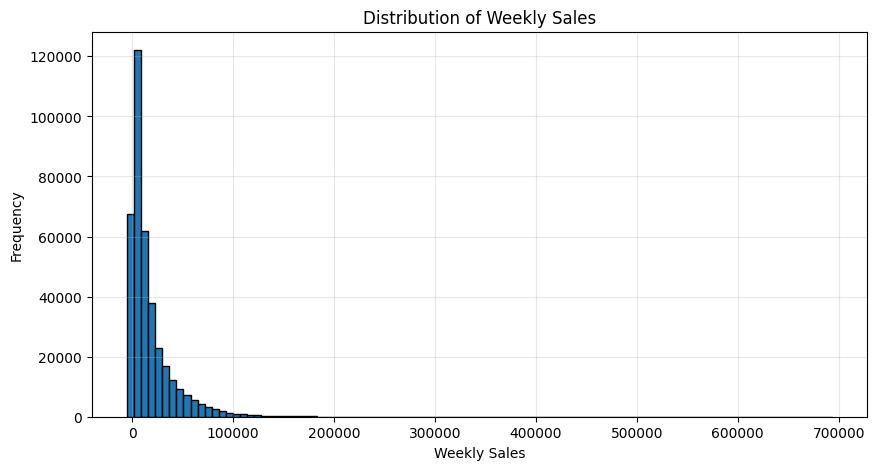

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.hist(
    nbeats_clean["y"],
    bins=100,
    edgecolor="black"
)

plt.title("Distribution of Weekly Sales")
plt.xlabel("Weekly Sales")
plt.ylabel("Frequency")

plt.grid(alpha=0.3)

plt.show()

In [32]:
nbeats_clean["y"].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])

,y
count,381811.000000
mean,17505.428407
std,23273.215244
min,-4988.940000
1%,72.762000
5%,387.830000
25%,3153.125000
50%,9070.140000
75%,22179.715000
95%,63787.950000


#უარყოფითი გაყიდვები შეიძლება ნიშნავდეს პროდუქტის დაბრუნებას ან წინა გაყიდვის კორექტირებას. ამიტომ ამ ეტაპზე მათ არ ვშლით — ჯერ ვარკვევთ:

რამდენი უარყოფითი ჩანაწერია;
მონაცემების რამდენ პროცენტს შეადგენს;
რამდენ სერიაში გვხვდება;
რამდენად დიდია მათი საერთო მოცულობა.

In [33]:
negative_sales = nbeats_clean[nbeats_clean["y"] < 0]

print("Negative sales rows:", len(negative_sales))

print(
    "Percentage of all rows:",
    round(len(negative_sales) / len(nbeats_clean) * 100, 4),
    "%"
)

print(
    "Series containing negative sales:",
    negative_sales["unique_id"].nunique()
)

print(
    "Total negative sales amount:",
    round(negative_sales["y"].sum(), 2)
)

print(
    "Most negative value:",
    negative_sales["y"].min()
)

display(
    negative_sales
    .sort_values("y")
    .head(20)
)

Negative sales rows: 41
Percentage of all rows: 0.0107 %
Series containing negative sales: 32
Total negative sales amount: -9622.64
Most negative value: -4988.94


,Store,Dept,ds,y,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size,unique_id
180041,28,6,2010-10-08,-4988.94,False,71.82,3.013,NaN,NaN,NaN,NaN,NaN,126.279167,14.313,A,206302,28_6
177348,28,32,2011-03-25,-1321.48,False,54.40,3.909,NaN,NaN,NaN,NaN,NaN,128.616064,14.021,A,206302,28_32
279275,3,32,2011-09-30,-1008.96,False,82.58,3.355,NaN,NaN,NaN,NaN,NaN,220.085696,7.567,B,37392,3_32
241886,35,16,2012-08-24,-771.90,False,72.93,3.834,5726.77,NaN,57.08,5332.71,4133.91,142.310593,8.839,B,103681,35_16
241890,35,16,2012-09-21,-244.17,False,66.10,4.038,6982.10,87.37,6.00,2085.94,9129.21,142.679817,8.839,B,103681,35_16
180036,28,6,2010-09-03,-157.63,False,83.12,3.087,NaN,NaN,NaN,NaN,NaN,126.101935,14.180,A,206302,28_6
97514,1,6,2012-08-10,-139.65,False,85.05,3.494,11436.22,245.00,6.85,6964.26,4836.22,221.958433,6.908,A,151315,1_6
318432,44,9,2011-12-16,-132.46,False,27.85,3.282,29.40,NaN,6.75,NaN,1041.62,129.898065,6.078,C,39910,44_9
187427,29,36,2012-07-20,-117.00,False,76.57,3.610,1142.93,212.35,8.11,368.45,1625.35,138.233193,9.419,B,93638,29_36
124766,22,6,2012-01-13,-106.34,False,39.00,3.523,2325.12,19455.80,6.06,520.21,5824.45,140.704821,7.503,B,119557,22_6


#შემდეგი ნაბიჯი — Outlier-ების რაოდენობრივი ანალიზი

IQR მეთოდი მონაცემებს ავტომატურად არ შეცვლის. მხოლოდ დაგვანახებს, რამდენი მნიშვნელობა ხვდება სტატისტიკური ზედა და ქვედა საზღვრების გარეთ.

გაუშვი მხოლოდ ეს სელი:

In [34]:
q1 = nbeats_clean["y"].quantile(0.25)
q3 = nbeats_clean["y"].quantile(0.75)

iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = nbeats_clean[
    (nbeats_clean["y"] < lower_bound) |
    (nbeats_clean["y"] > upper_bound)
]

print("Q1:", round(q1, 2))
print("Q3:", round(q3, 2))
print("IQR:", round(iqr, 2))
print("Lower bound:", round(lower_bound, 2))
print("Upper bound:", round(upper_bound, 2))

print("\nOutlier rows:", len(outliers))
print(
    "Outlier percentage:",
    round(len(outliers) / len(nbeats_clean) * 100, 2),
    "%"
)

print(
    "Series containing outliers:",
    outliers["unique_id"].nunique()
)

Q1: 3153.12
Q3: 22179.72
IQR: 19026.59
Lower bound: -25386.76
Upper bound: 50719.6

Outlier rows: 31162
Outlier percentage: 8.16 %
Series containing outliers: 604


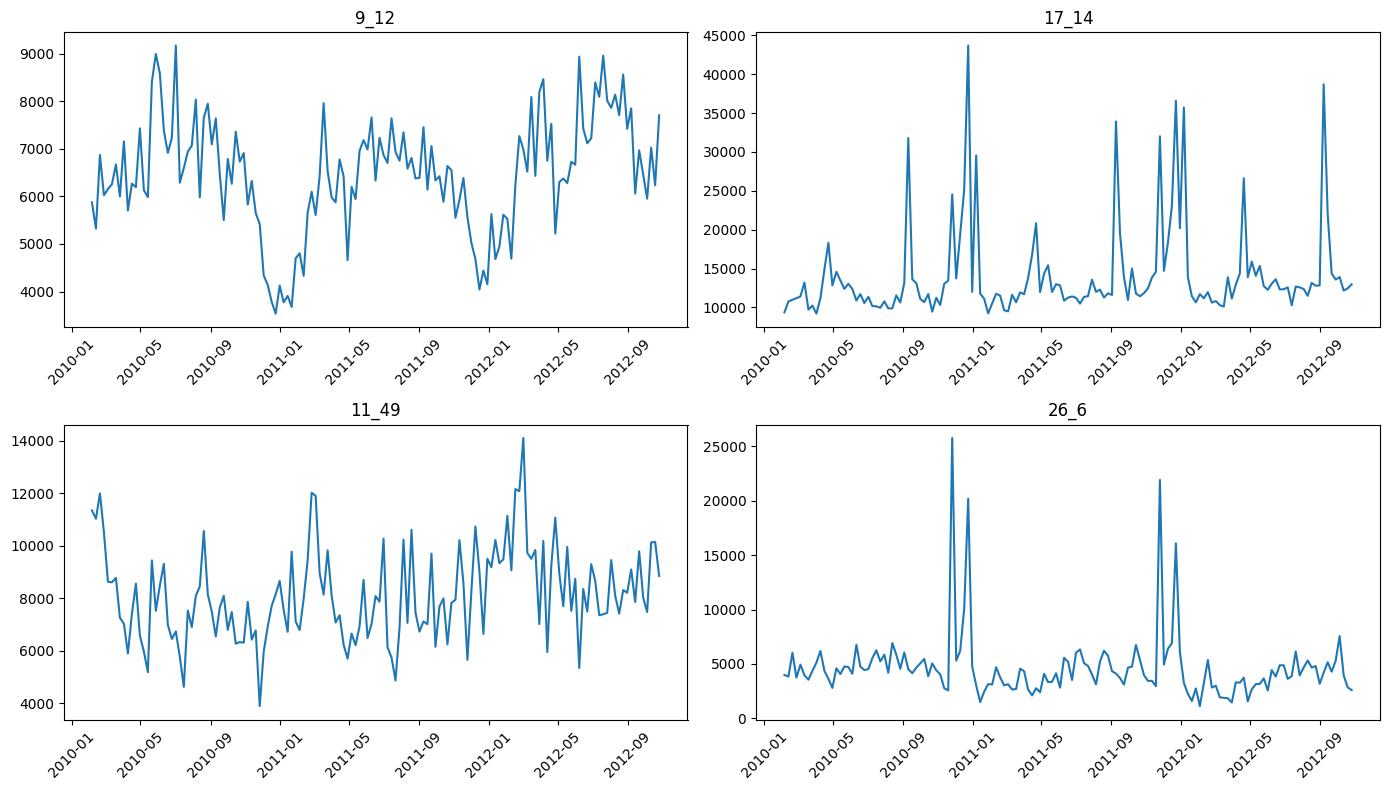

In [35]:
import matplotlib.pyplot as plt
import random

random.seed(42)

sample_ids = random.sample(
    list(nbeats_clean["unique_id"].unique()),
    4
)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, uid in zip(axes.flatten(), sample_ids):
    temp = nbeats_clean[nbeats_clean["unique_id"] == uid]

    ax.plot(temp["ds"], temp["y"])
    ax.set_title(uid)
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

#მონაცემების გაყოფა გვაქვს 92 კვირა 52 კვირა სატრენინგო 40 ვალიდაციის

In [36]:
VAL_SIZE = 40

train_df = []
val_df = []

for _, group in nbeats_clean.groupby("unique_id"):
    train_df.append(group.iloc[:-VAL_SIZE])
    val_df.append(group.iloc[-VAL_SIZE:])

train_df = (
    pd.concat(train_df)
    .reset_index(drop=True)
)

val_df = (
    pd.concat(val_df)
    .reset_index(drop=True)
)

print("Training rows:", len(train_df))
print("Validation rows:", len(val_df))

print("\nTraining series:", train_df["unique_id"].nunique())
print("Validation series:", val_df["unique_id"].nunique())

print("\nTraining date range:")
print(train_df["ds"].min(), "→", train_df["ds"].max())

print("\nValidation date range:")
print(val_df["ds"].min(), "→", val_df["ds"].max())

Training rows: 274971
Validation rows: 106840

Training series: 2671
Validation series: 2671

Training date range:
2010-02-05 00:00:00 → 2012-01-20 00:00:00

Validation date range:
2012-01-27 00:00:00 → 2012-10-26 00:00:00


In [37]:
from neuralforecast import NeuralForecast
from neuralforecast.models import NBEATS
from neuralforecast.losses.pytorch import MAE

model = NBEATS(
    h=40,
    input_size=52,
    loss=MAE(),
    scaler_type="robust",
    learning_rate=1e-3,
    max_steps=1000,
    batch_size=32,
    windows_batch_size=512,
    random_seed=42
)

nf = NeuralForecast(
    models=[model],
    freq="W-FRI"
)

print(model)

INFO:lightning_fabric.utilities.seed:Seed set to 42


NBEATS


In [38]:
train_nbeats = (
    train_df[["unique_id", "ds", "y"]]
    .copy()
    .sort_values(["unique_id", "ds"])
    .reset_index(drop=True)
)

print("Missing values:")
print(train_nbeats.isna().sum())

nf.fit(df=train_nbeats)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores


Missing values:
unique_id    0
ds           0
y            0
dtype: int64


INFO:pytorch_lightning.callbacks.model_summary:
  | Name                | Type          | Params | Mode 
--------------------------------------------------------------
0 | loss                | MAE           | 0      | train
1 | hist_cat_embeddings | ModuleList    | 0      | train
2 | futr_cat_embeddings | ModuleList    | 0      | train
3 | stat_cat_embeddings | ModuleList    | 0      | train
4 | padder_train        | ConstantPad1d | 0      | train
5 | scaler              | TemporalNorm  | 0      | train
6 | blocks              | ModuleList    | 2.6 M  | train
--------------------------------------------------------------
2.6 M     Trainable params
7.5 K     Non-trainable params
2.6 M     Total params
10.332    Total estimated model params size (MB)
34        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=1000` reached.


In [39]:
# მიმდინარე N-BEATS ობიექტის თავიდან გაწვრთნა
nf.fit(df=train_nbeats)

# Train პერიოდის დასრულების შემდეგ მომდევნო 40 კვირის პროგნოზი
predictions = nf.predict()

print(predictions.head())
print("Prediction shape:", predictions.shape)
print("Forecast dates:", predictions["ds"].min(), "→", predictions["ds"].max())

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.callbacks.model_summary:
  | Name                | Type          | Params | Mode 
--------------------------------------------------------------
0 | loss                | MAE           | 0      | train
1 | hist_cat_embeddings | ModuleList    | 0      | train
2 | futr_cat_embeddings | ModuleList    | 0      | train
3 | stat_cat_embeddings | ModuleList    | 0      | train
4 | padder_train        | ConstantPad1d | 0      | train
5 | scaler              | TemporalNorm  | 0      | train
6 | blocks              | ModuleList    | 2.6 M  | train
--------------------------------------------------------------
2.6 M     Trainable params
7.5 K     Non-trainable params
2.6 M     Total params
10.332    Total estimated model params size (MB)
34        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_steps=1000` reached.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Predicting: |          | 0/? [00:00<?, ?it/s]

  unique_id         ds        NBEATS
0      10_1 2012-01-27  30583.365234
1      10_1 2012-02-03  35680.261719
2      10_1 2012-02-10  37539.085938
3      10_1 2012-02-17  44174.394531
4      10_1 2012-02-24  40378.328125
Prediction shape: (106840, 3)
Forecast dates: 2012-01-27 00:00:00 → 2012-10-26 00:00:00


In [40]:
print("Predictions columns:", predictions.columns.tolist())
print("Validation columns:", val_df.columns.tolist())

print("\nPredictions shape:", predictions.shape)
print("Validation shape:", val_df.shape)

print("\nPredictions sample:")
display(predictions.head())

print("\nValidation sample:")
display(val_df[["unique_id", "ds", "y"]].head())

Predictions columns: ['unique_id', 'ds', 'NBEATS']
Validation columns: ['Store', 'Dept', 'ds', 'y', 'IsHoliday', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'Type', 'Size', 'unique_id']

Predictions shape: (106840, 3)
Validation shape: (106840, 17)

Predictions sample:


,unique_id,ds,NBEATS
0,10_1,2012-01-27,30583.365234
1,10_1,2012-02-03,35680.261719
2,10_1,2012-02-10,37539.085938
3,10_1,2012-02-17,44174.394531
4,10_1,2012-02-24,40378.328125



Validation sample:


,unique_id,ds,y
0,10_1,2012-01-27,32559.13
1,10_1,2012-02-03,36444.00
2,10_1,2012-02-10,50434.11
3,10_1,2012-02-17,74930.33
4,10_1,2012-02-24,28751.57


In [41]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

results = val_df[["unique_id", "ds", "y"]].merge(
    predictions,
    on=["unique_id", "ds"],
    how="inner"
)

print("Merged shape:", results.shape)

mae = mean_absolute_error(results["y"], results["NBEATS"])
rmse = np.sqrt(mean_squared_error(results["y"], results["NBEATS"]))
r2 = r2_score(results["y"], results["NBEATS"])

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

display(results.head())

Merged shape: (106840, 4)
MAE  : 1807.96
RMSE : 3782.12
R²   : 0.9723


,unique_id,ds,y,NBEATS
0,10_1,2012-01-27,32559.13,30583.365234
1,10_1,2012-02-03,36444.00,35680.261719
2,10_1,2012-02-10,50434.11,37539.085938
3,10_1,2012-02-17,74930.33,44174.394531
4,10_1,2012-02-24,28751.57,40378.328125


In [42]:
results_detailed = val_df[
    ["unique_id", "ds", "y", "IsHoliday"]
].merge(
    predictions,
    on=["unique_id", "ds"],
    how="inner"
)

results_detailed["absolute_error"] = (
    results_detailed["y"] - results_detailed["NBEATS"]
).abs()

results_detailed["weight"] = np.where(
    results_detailed["IsHoliday"],
    5.0,
    1.0
)

wmae = (
    results_detailed["weight"]
    * results_detailed["absolute_error"]
).sum() / results_detailed["weight"].sum()

holiday_mae = results_detailed.loc[
    results_detailed["IsHoliday"], "absolute_error"
].mean()

non_holiday_mae = results_detailed.loc[
    ~results_detailed["IsHoliday"], "absolute_error"
].mean()

print(f"Overall MAE     : {mae:.2f}")
print(f"Official WMAE  : {wmae:.2f}")
print(f"Holiday MAE     : {holiday_mae:.2f}")
print(f"Non-Holiday MAE : {non_holiday_mae:.2f}")

print("\nHoliday rows:", results_detailed["IsHoliday"].sum())
print("Total rows:", len(results_detailed))

Overall MAE     : 1807.96
Official WMAE  : 1869.07
Holiday MAE     : 2174.61
Non-Holiday MAE : 1788.67

Holiday rows: 5342
Total rows: 106840


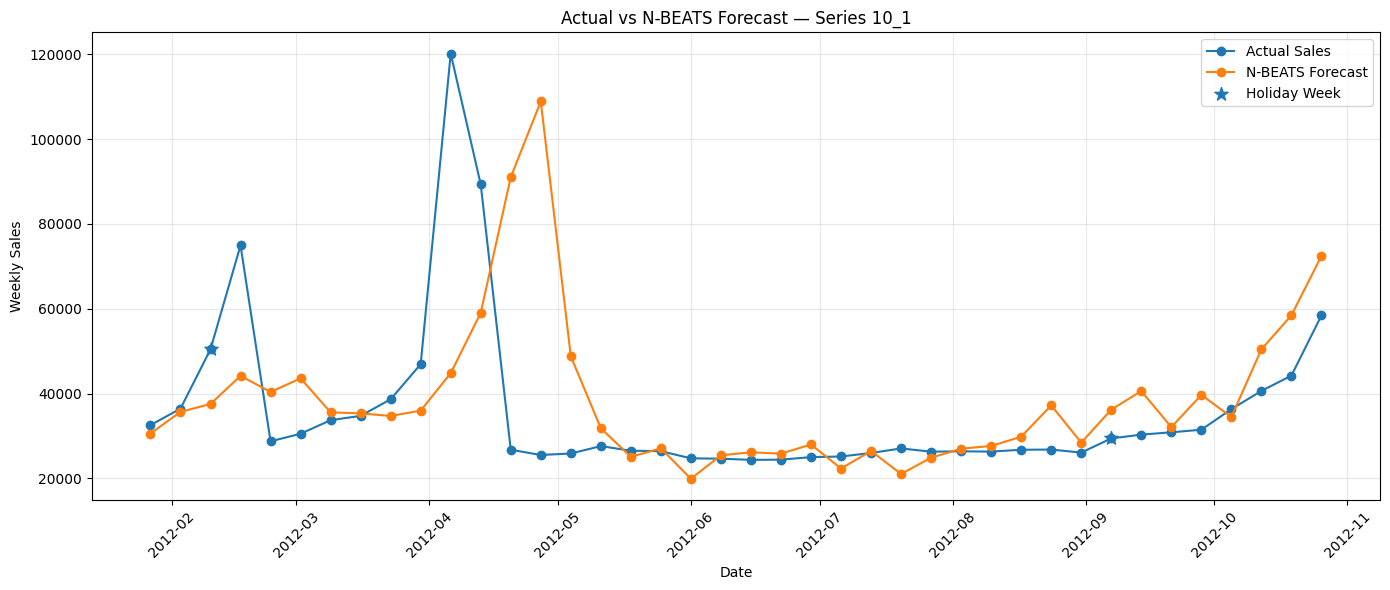

In [43]:
import matplotlib.pyplot as plt

series_id = "10_1"

plot_data = (
    results_detailed[
        results_detailed["unique_id"] == series_id
    ]
    .sort_values("ds")
    .copy()
)

plt.figure(figsize=(14, 6))

plt.plot(
    plot_data["ds"],
    plot_data["y"],
    marker="o",
    label="Actual Sales"
)

plt.plot(
    plot_data["ds"],
    plot_data["NBEATS"],
    marker="o",
    label="N-BEATS Forecast"
)

holiday_points = plot_data[plot_data["IsHoliday"]]

plt.scatter(
    holiday_points["ds"],
    holiday_points["y"],
    s=100,
    marker="*",
    label="Holiday Week"
)

plt.title(f"Actual vs N-BEATS Forecast — Series {series_id}")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.xticks(rotation=45)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

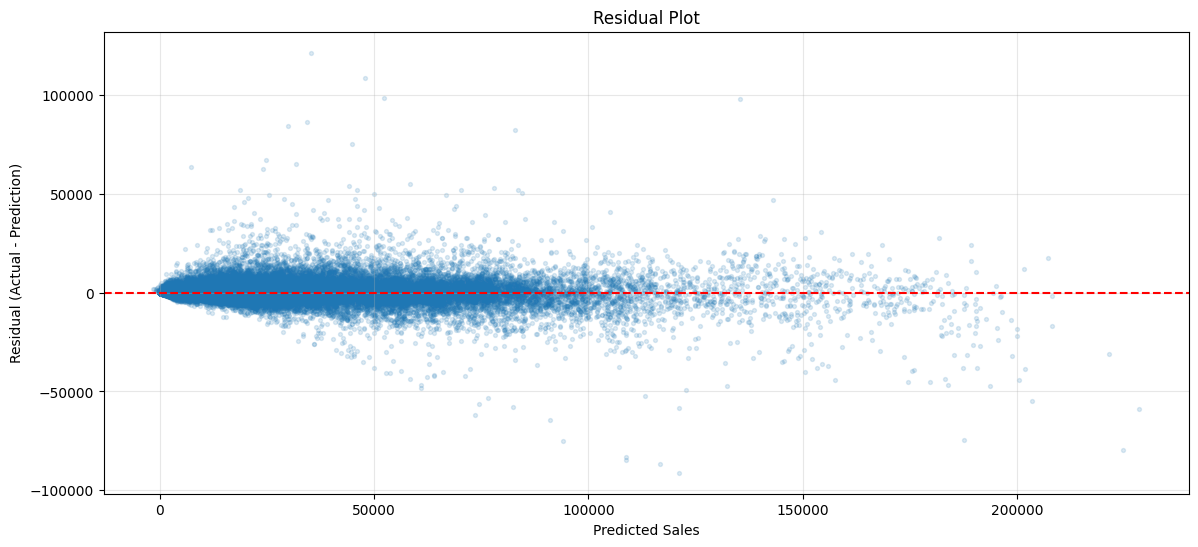

In [44]:
results_detailed["Residual"] = (
    results_detailed["y"]
    - results_detailed["NBEATS"]
)

plt.figure(figsize=(14,6))

plt.scatter(
    results_detailed["NBEATS"],
    results_detailed["Residual"],
    alpha=0.15,
    s=8
)

plt.axhline(
    0,
    color="red",
    linestyle="--"
)

plt.title("Residual Plot")
plt.xlabel("Predicted Sales")
plt.ylabel("Residual (Actual - Prediction)")
plt.grid(alpha=0.3)

plt.show()

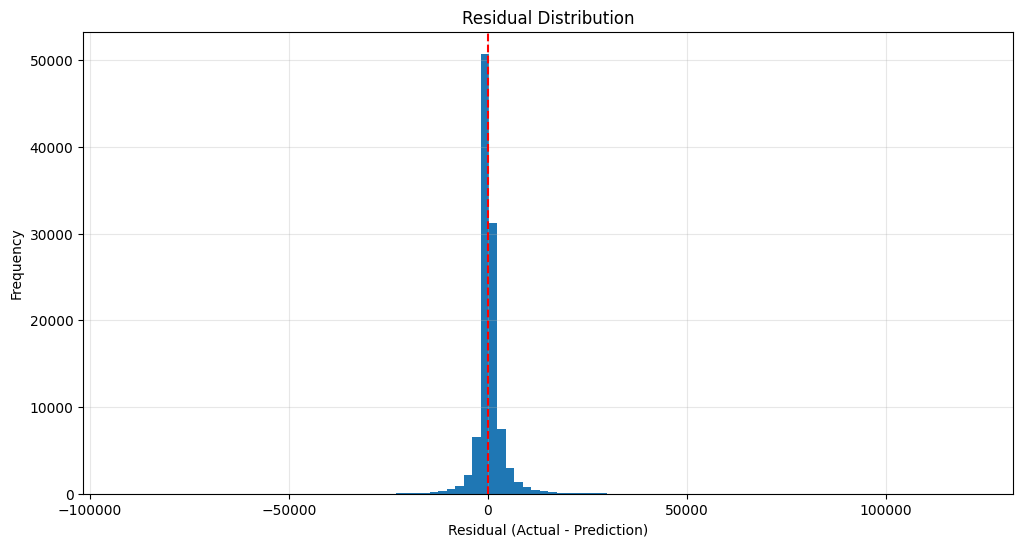

In [45]:
plt.figure(figsize=(12,6))

plt.hist(
    results_detailed["Residual"],
    bins=100
)

plt.axvline(
    0,
    color="red",
    linestyle="--"
)

plt.title("Residual Distribution")
plt.xlabel("Residual (Actual - Prediction)")
plt.ylabel("Frequency")

plt.grid(alpha=0.3)

plt.show()

Top 15 worst series by WMAE:


,unique_id,Store,Dept,MAE,WMAE,RMSE,Relative_MAE_Percent,Max_Absolute_Error,Holiday_MAE
325,14_92,14,92,25432.41,25797.62,31913.17,15.12,79685.12,27623.66
49,10_72,10,72,15677.99,22132.67,23600.79,13.18,97787.29,54406.07
753,20_72,20,72,15501.23,20387.79,22292.26,20.29,82240.31,44820.59
328,14_95,14,95,19186.31,19006.31,24857.59,15.04,74680.38,18106.34
1727,35_72,35,72,14566.77,18414.51,17933.22,20.30,55117.13,37653.22
312,14_72,14,72,14661.14,16635.43,18805.54,19.52,58118.61,26506.90
569,18_92,18,92,15690.07,16013.79,16654.60,24.11,25946.40,17632.44
323,14_90,14,90,15533.69,15599.56,18944.03,16.04,47129.32,15928.88
195,13_1,13,1,15733.33,15153.10,28251.79,34.20,98455.21,12251.92
292,14_38,14,38,14322.63,14971.48,17187.93,15.25,31831.41,18215.74


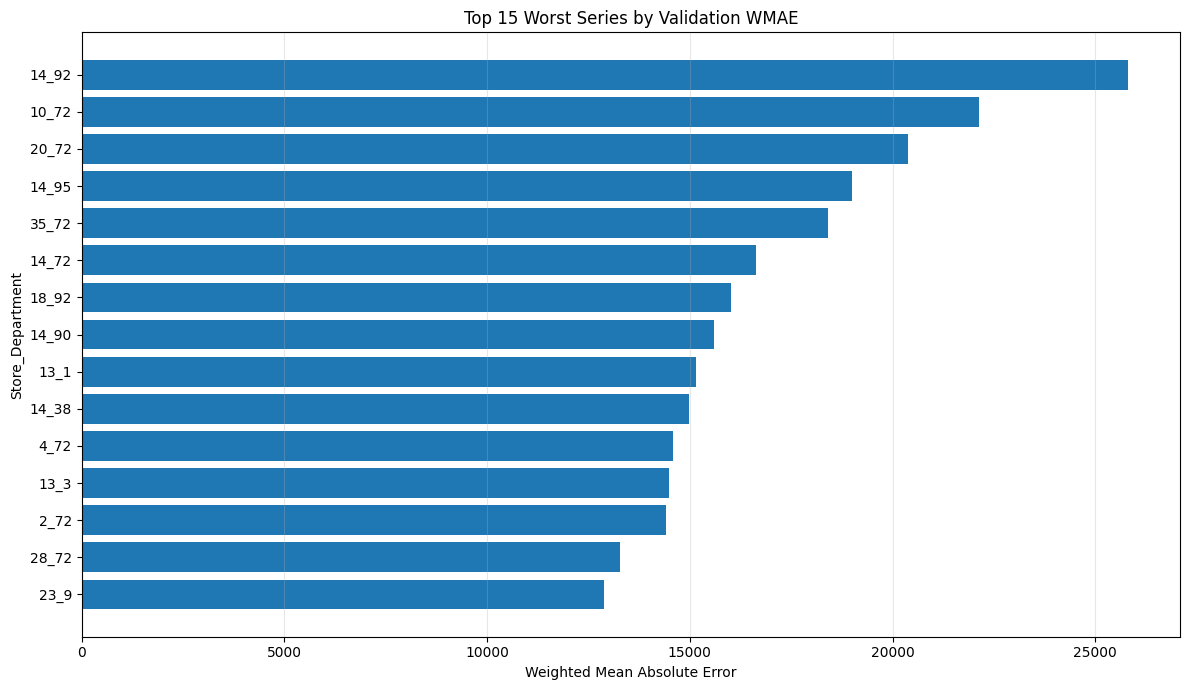

In [46]:
series_metrics = (
    results_detailed
    .groupby("unique_id")
    .apply(
        lambda group: pd.Series({
            "MAE": group["absolute_error"].mean(),
            "RMSE": np.sqrt(np.mean(group["Residual"] ** 2)),
            "WMAE": np.average(
                group["absolute_error"],
                weights=group["weight"]
            ),
            "Mean_Actual_Sales": group["y"].abs().mean(),
            "Max_Absolute_Error": group["absolute_error"].max(),
            "Holiday_MAE": (
                group.loc[group["IsHoliday"], "absolute_error"].mean()
                if group["IsHoliday"].any()
                else np.nan
            )
        }),
        include_groups=False
    )
    .reset_index()
)

series_metrics["Relative_MAE_Percent"] = (
    series_metrics["MAE"]
    / series_metrics["Mean_Actual_Sales"].replace(0, np.nan)
    * 100
)

series_metrics[["Store", "Dept"]] = (
    series_metrics["unique_id"]
    .str.split("_", expand=True)
    .astype(int)
)

worst_series = (
    series_metrics
    .sort_values("WMAE", ascending=False)
    .head(15)
)

print("Top 15 worst series by WMAE:")
display(
    worst_series[
        [
            "unique_id",
            "Store",
            "Dept",
            "MAE",
            "WMAE",
            "RMSE",
            "Relative_MAE_Percent",
            "Max_Absolute_Error",
            "Holiday_MAE"
        ]
    ].round(2)
)

plt.figure(figsize=(12, 7))

plt.barh(
    worst_series["unique_id"][::-1],
    worst_series["WMAE"][::-1]
)

plt.title("Top 15 Worst Series by Validation WMAE")
plt.xlabel("Weighted Mean Absolute Error")
plt.ylabel("Store_Department")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

Top 15 worst departments by WMAE:


,Dept,Series_Count,Rows,MAE,WMAE,RMSE,Relative_MAE_Percent,Max_Absolute_Error
54,72,40.0,1600.0,7436.20,9281.44,11431.04,15.85,97787.29
51,65,1.0,40.0,7798.59,7965.70,9459.41,16.56,18139.71
35,38,45.0,1800.0,6411.18,6429.72,8288.71,10.30,35371.89
65,92,45.0,1800.0,4928.59,5164.84,8077.09,6.32,79685.12
0,1,45.0,1800.0,5020.37,5039.42,11651.58,26.91,121441.77
68,95,45.0,1800.0,4385.12,4466.38,6808.02,6.12,74680.38
8,9,41.0,1640.0,3882.52,3813.76,5884.93,16.50,42478.39
6,7,45.0,1800.0,3576.85,3418.66,5734.55,17.73,42150.59
4,5,42.0,1680.0,3212.31,3406.87,5161.24,17.26,43923.62
67,94,28.0,1120.0,3269.44,3205.18,4527.25,6.83,24675.73


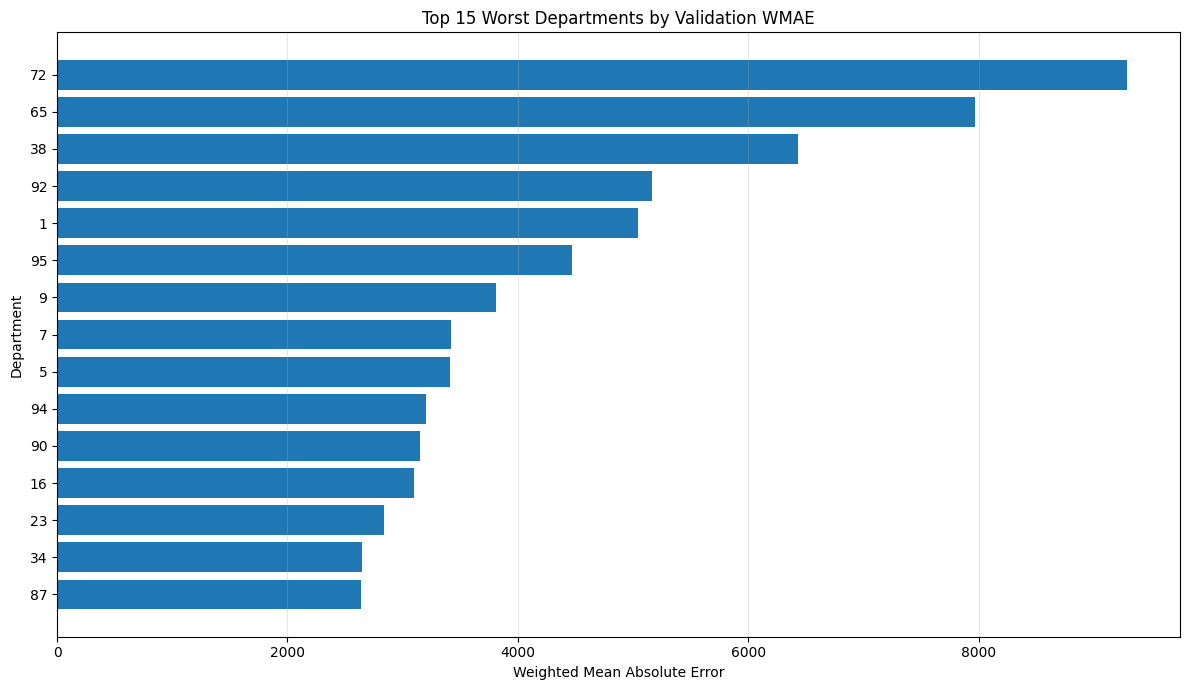

In [47]:
dept_metrics = (
    results_detailed
    .assign(
        Dept=results_detailed["unique_id"]
        .str.split("_")
        .str[1]
        .astype(int)
    )
    .groupby("Dept")
    .apply(
        lambda group: pd.Series({
            "Rows": len(group),
            "Series_Count": group["unique_id"].nunique(),
            "MAE": group["absolute_error"].mean(),
            "WMAE": np.average(
                group["absolute_error"],
                weights=group["weight"]
            ),
            "RMSE": np.sqrt(np.mean(group["Residual"] ** 2)),
            "Mean_Actual_Sales": group["y"].abs().mean(),
            "Max_Absolute_Error": group["absolute_error"].max()
        }),
        include_groups=False
    )
    .reset_index()
)

dept_metrics["Relative_MAE_Percent"] = (
    dept_metrics["MAE"]
    / dept_metrics["Mean_Actual_Sales"].replace(0, np.nan)
    * 100
)

worst_departments = (
    dept_metrics
    .sort_values("WMAE", ascending=False)
    .head(15)
)

print("Top 15 worst departments by WMAE:")

display(
    worst_departments[
        [
            "Dept",
            "Series_Count",
            "Rows",
            "MAE",
            "WMAE",
            "RMSE",
            "Relative_MAE_Percent",
            "Max_Absolute_Error"
        ]
    ].round(2)
)

plt.figure(figsize=(12, 7))

plt.barh(
    worst_departments["Dept"].astype(str)[::-1],
    worst_departments["WMAE"][::-1]
)

plt.title("Top 15 Worst Departments by Validation WMAE")
plt.xlabel("Weighted Mean Absolute Error")
plt.ylabel("Department")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

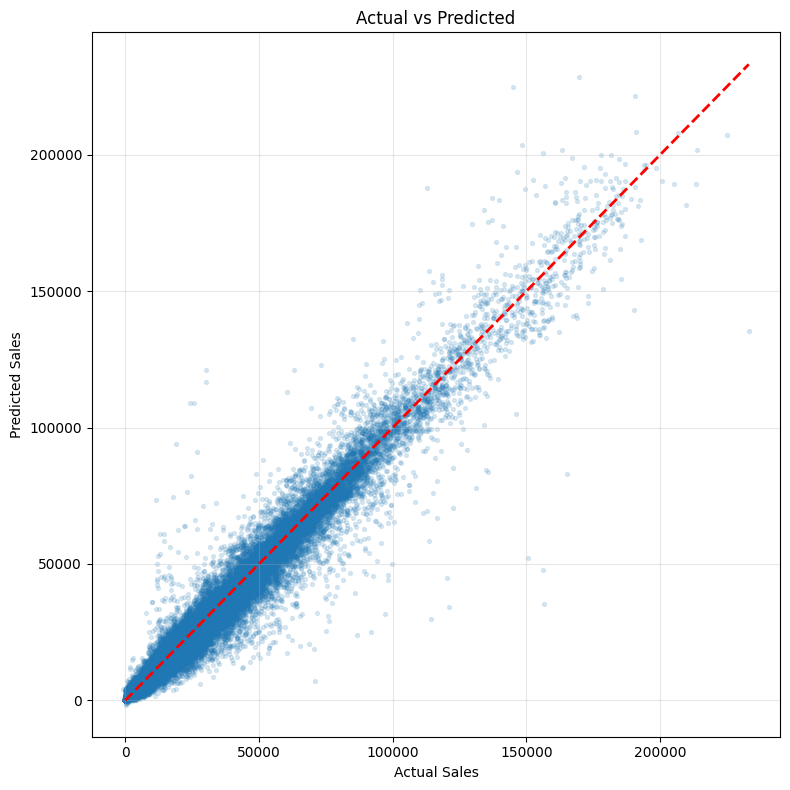

In [48]:
plt.figure(figsize=(8,8))

plt.scatter(
    results_detailed["y"],
    results_detailed["NBEATS"],
    alpha=0.15,
    s=8
)

max_val = max(
    results_detailed["y"].max(),
    results_detailed["NBEATS"].max()
)

plt.plot(
    [0,max_val],
    [0,max_val],
    'r--',
    linewidth=2
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")

plt.title("Actual vs Predicted")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [49]:
# საჭირო ბიბლიოთეკების დაყენება
!pip install -q mlflow dagshub

import mlflow
import dagshub

# DagsHub რეპოზიტორიის მონაცემები
REPO_OWNER = "tsarc21"
REPO_NAME = "Walmart-Recruiting---Store-Sales-Forecasting"

# Colab-ის დაკავშირება DagsHub-ის MLflow Tracking Server-თან
dagshub.init(
    repo_owner=REPO_OWNER,
    repo_name=REPO_NAME,
    mlflow=True
)

# პროექტის ყველა N-BEATS ექსპერიმენტი ამ სახელის ქვეშ შეინახება
EXPERIMENT_NAME = "Walmart_NBEATS"

experiment = mlflow.set_experiment(EXPERIMENT_NAME)

print("MLflow tracking successfully initialized.")
print("Tracking URI:", mlflow.get_tracking_uri())
print("Experiment name:", experiment.name)
print("Experiment ID:", experiment.experiment_id)

Initialized MLflow to track repo "tsarc21/Walmart-Recruiting---Store-Sales-Forecasting"

Repository tsarc21/Walmart-Recruiting---Store-Sales-Forecasting initialized!

MLflow tracking successfully initialized.
Tracking URI: https://dagshub.com/tsarc21/Walmart-Recruiting---Store-Sales-Forecasting.mlflow
Experiment name: Walmart_NBEATS
Experiment ID: 13


In [50]:
import numpy as np
import mlflow

# უსაფრთხოებისთვის ვამოწმებთ, ხომ არ არის დარჩენილი ძველი აქტიური Run
if mlflow.active_run() is not None:
    mlflow.end_run()

# ძირითადი მეტრიკების გამოთვლა არსებული validation შედეგებიდან
baseline_mae = results_detailed["absolute_error"].mean()

baseline_rmse = np.sqrt(
    np.mean(results_detailed["Residual"] ** 2)
)

ss_res = np.sum(
    (results_detailed["y"] - results_detailed["NBEATS"]) ** 2
)

ss_tot = np.sum(
    (results_detailed["y"] - results_detailed["y"].mean()) ** 2
)

baseline_r2 = 1 - (ss_res / ss_tot)

baseline_wmae = np.average(
    results_detailed["absolute_error"],
    weights=results_detailed["weight"]
)

holiday_mae = results_detailed.loc[
    results_detailed["IsHoliday"],
    "absolute_error"
].mean()

non_holiday_mae = results_detailed.loc[
    ~results_detailed["IsHoliday"],
    "absolute_error"
].mean()

# Baseline Run-ის შექმნა
with mlflow.start_run(run_name="NBEATS_Baseline") as run:

    # მოდელის ჰიპერპარამეტრები
    mlflow.log_params({
        "model_name": "NBEATS",
        "forecast_horizon": 40,
        "input_size": 52,
        "learning_rate": 0.001,
        "max_steps": 1000,
        "batch_size": 32,
        "windows_batch_size": 512,
        "scaler_type": "robust",
        "loss_function": "MAE",
        "random_seed": 42
    })

    # მონაცემებთან დაკავშირებული პარამეტრები
    mlflow.log_params({
        "number_of_series": results_detailed["unique_id"].nunique(),
        "validation_rows": len(results_detailed),
        "validation_size_weeks": 40,
        "train_start_date": str(train_df["ds"].min().date()),
        "train_end_date": str(train_df["ds"].max().date()),
        "validation_start_date": str(val_df["ds"].min().date()),
        "validation_end_date": str(val_df["ds"].max().date())
    })

    # შეფასების მეტრიკები
    mlflow.log_metrics({
        "MAE": float(baseline_mae),
        "RMSE": float(baseline_rmse),
        "R2": float(baseline_r2),
        "WMAE": float(baseline_wmae),
        "Holiday_MAE": float(holiday_mae),
        "Non_Holiday_MAE": float(non_holiday_mae)
    })

    # დამატებითი აღწერითი Tags
    mlflow.set_tags({
        "model_family": "NeuralForecast",
        "model_stage": "baseline",
        "dataset": "Walmart Store Sales Forecasting",
        "frequency": "weekly",
        "validation_strategy": "last_40_weeks",
        "project_type": "time_series_forecasting",
        "run_status": "baseline_completed"
    })

    run_id = run.info.run_id

print("Baseline Run successfully logged to MLflow/DagsHub.")
print("Run ID:", run_id)
print("\nLogged metrics:")
print(f"MAE: {baseline_mae:.2f}")
print(f"RMSE: {baseline_rmse:.2f}")
print(f"R²: {baseline_r2:.4f}")
print(f"WMAE: {baseline_wmae:.2f}")
print(f"Holiday MAE: {holiday_mae:.2f}")
print(f"Non-Holiday MAE: {non_holiday_mae:.2f}")

🏃 View run NBEATS_Baseline at: https://dagshub.com/tsarc21/Walmart-Recruiting---Store-Sales-Forecasting.mlflow/#/experiments/13/runs/ae547edf4f0f4372b140691e3f01610b
🧪 View experiment at: https://dagshub.com/tsarc21/Walmart-Recruiting---Store-Sales-Forecasting.mlflow/#/experiments/13
Baseline Run successfully logged to MLflow/DagsHub.
Run ID: ae547edf4f0f4372b140691e3f01610b

Logged metrics:
MAE: 1807.96
RMSE: 3782.12
R²: 0.9723
WMAE: 1869.07
Holiday MAE: 2174.61
Non-Holiday MAE: 1788.67


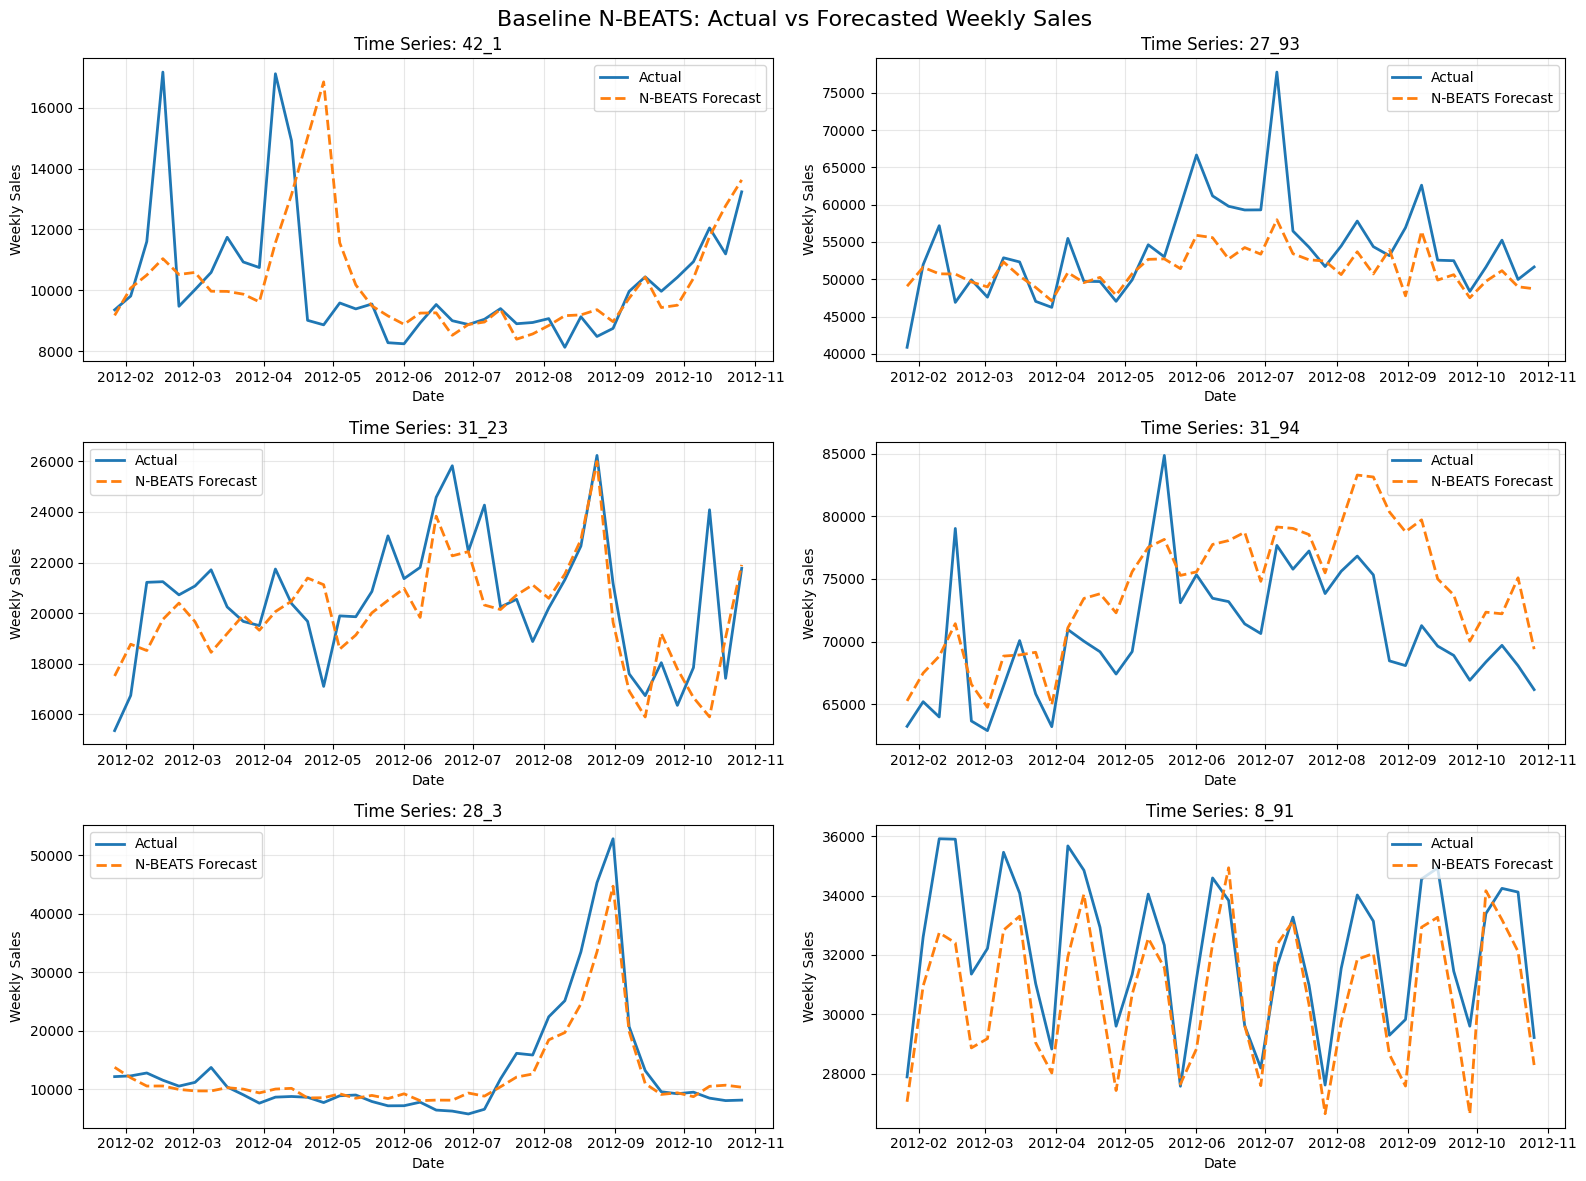

In [51]:
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(42)

sample_ids = np.random.choice(
    results_detailed["unique_id"].unique(),
    size=6,
    replace=False
)

fig, axes = plt.subplots(3, 2, figsize=(16, 12))
axes = axes.flatten()

for ax, uid in zip(axes, sample_ids):

    series_data = (
        results_detailed[
            results_detailed["unique_id"] == uid
        ]
        .sort_values("ds")
    )

    ax.plot(
        series_data["ds"],
        series_data["y"],
        label="Actual",
        linewidth=2
    )

    ax.plot(
        series_data["ds"],
        series_data["NBEATS"],
        label="N-BEATS Forecast",
        linestyle="--",
        linewidth=2
    )

    ax.set_title(f"Time Series: {uid}")
    ax.set_xlabel("Date")
    ax.set_ylabel("Weekly Sales")
    ax.grid(alpha=0.3)
    ax.legend()

plt.suptitle(
    "Baseline N-BEATS: Actual vs Forecasted Weekly Sales",
    fontsize=16
)

plt.tight_layout()
plt.show()

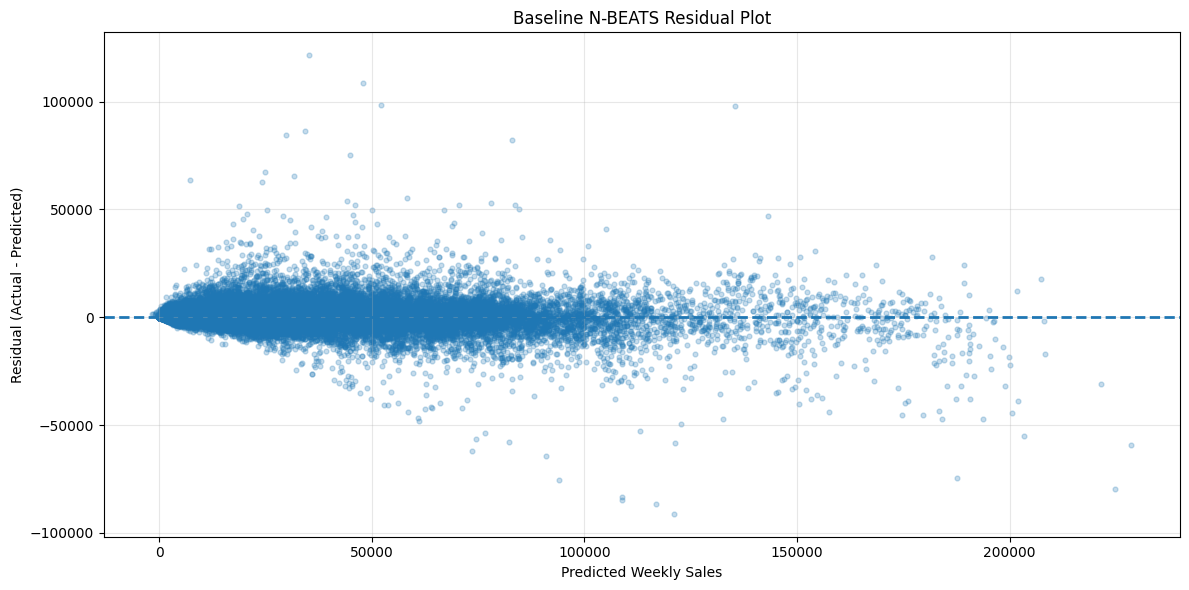

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.scatter(
    results_detailed["NBEATS"],
    results_detailed["Residual"],
    alpha=0.25,
    s=12
)

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=2
)

plt.title("Baseline N-BEATS Residual Plot")
plt.xlabel("Predicted Weekly Sales")
plt.ylabel("Residual (Actual - Predicted)")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

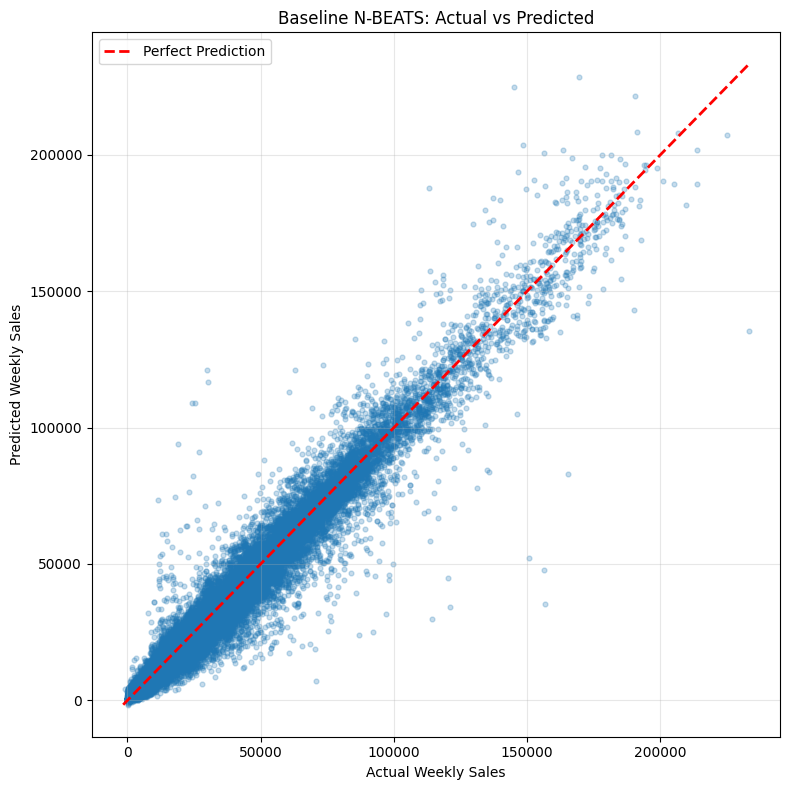

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))

plt.scatter(
    results_detailed["y"],
    results_detailed["NBEATS"],
    alpha=0.25,
    s=12
)

min_val = min(
    results_detailed["y"].min(),
    results_detailed["NBEATS"].min()
)

max_val = max(
    results_detailed["y"].max(),
    results_detailed["NBEATS"].max()
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    "r--",
    linewidth=2,
    label="Perfect Prediction"
)

plt.xlabel("Actual Weekly Sales")
plt.ylabel("Predicted Weekly Sales")
plt.title("Baseline N-BEATS: Actual vs Predicted")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

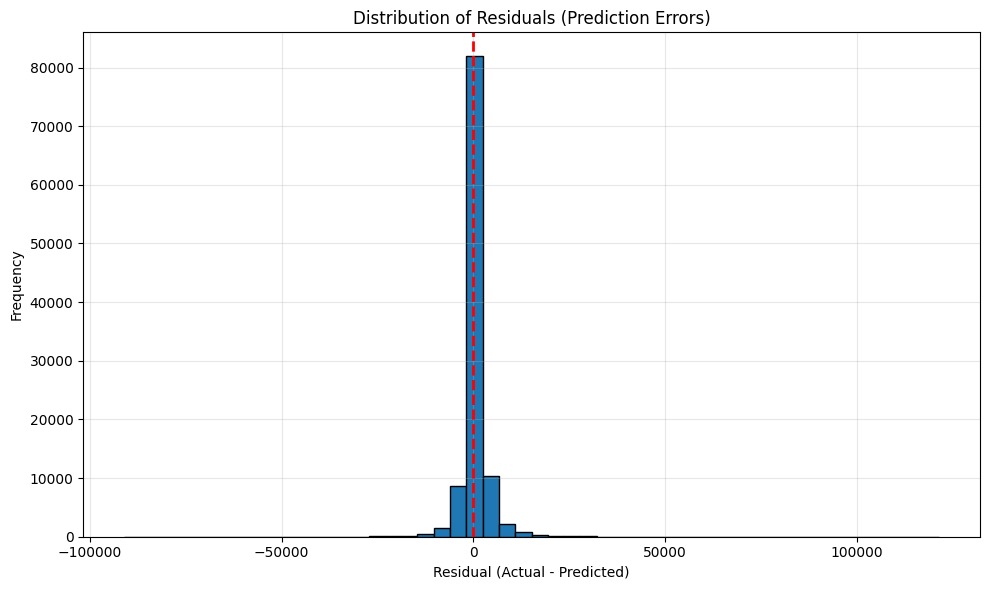

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.hist(
    results_detailed["Residual"],
    bins=50,
    edgecolor="black"
)

plt.axvline(
    0,
    color="red",
    linestyle="--",
    linewidth=2
)

plt.title("Distribution of Residuals (Prediction Errors)")
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [55]:
test_predictions = nf.predict()

prediction_column = [
    col for col in test_predictions.columns
    if col not in ["unique_id", "ds"]
][0]

test_predictions = test_predictions.rename(
    columns={prediction_column: "Weekly_Sales"}
)

test_predictions.head()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Predicting: |          | 0/? [00:00<?, ?it/s]

,unique_id,ds,Weekly_Sales
0,10_1,2012-01-27,30583.365234
1,10_1,2012-02-03,35680.261719
2,10_1,2012-02-10,37539.085938
3,10_1,2012-02-17,44174.394531
4,10_1,2012-02-24,40378.328125


In [56]:
import os

for root, dirs, files in os.walk("/content"):
    for file in files:
        if "sample" in file.lower():
            print(os.path.join(root, file))

/content/sampleSubmission.csv.zip


In [57]:
import os
import pandas as pd

# ყველა საჭირო ფაილის მოძებნა
found_files = {}

required_names = {
    "train": ["train.csv", "train.csv.zip"],
    "test": ["test.csv", "test.csv.zip"],
    "features": ["features.csv", "features.csv.zip"],
    "stores": ["stores.csv", "stores.csv.zip"],
    "sample": ["samplesubmission.csv", "samplesubmission.csv.zip"]
}

for root, dirs, files in os.walk("/content"):
    for file in files:
        file_lower = file.lower()

        for key, possible_names in required_names.items():
            if file_lower in possible_names:
                found_files[key] = os.path.join(root, file)

print("ნაპოვნი ფაილები:")
for key, path in found_files.items():
    print(f"{key}: {path}")

missing = [key for key in required_names if key not in found_files]

if missing:
    print("\nაკლია ფაილები:", missing)
    print("ატვირთე Kaggle-ის dataset ფაილები Colab-ში.")
else:
    train = pd.read_csv(found_files["train"])
    test = pd.read_csv(found_files["test"])
    features = pd.read_csv(found_files["features"])
    stores = pd.read_csv(found_files["stores"])
    sample_submission = pd.read_csv(found_files["sample"])

    train["Date"] = pd.to_datetime(train["Date"])
    test["Date"] = pd.to_datetime(test["Date"])
    features["Date"] = pd.to_datetime(features["Date"])

    print("\nმონაცემები წარმატებით ჩაიტვირთა")
    print("Train shape:", train.shape)
    print("Test shape:", test.shape)
    print("Features shape:", features.shape)
    print("Stores shape:", stores.shape)
    print("Sample submission shape:", sample_submission.shape)

    print("\nTrain პერიოდი:", train["Date"].min(), "→", train["Date"].max())
    print("Test პერიოდი:", test["Date"].min(), "→", test["Date"].max())
    print("სერიების რაოდენობა:", train.groupby(["Store", "Dept"]).ngroups)

ნაპოვნი ფაილები:
test: /content/drive/MyDrive/ML-store-sales-forecast/data/test.csv
stores: /content/drive/MyDrive/ML-store-sales-forecast/data/stores.csv
sample: /content/sampleSubmission.csv.zip
train: /content/drive/MyDrive/ML-store-sales-forecast/data/train.csv
features: /content/drive/MyDrive/ML-store-sales-forecast/data/features.csv

მონაცემები წარმატებით ჩაიტვირთა
Train shape: (421570, 5)
Test shape: (115064, 4)
Features shape: (8190, 12)
Stores shape: (45, 3)
Sample submission shape: (115064, 2)

Train პერიოდი: 2010-02-05 00:00:00 → 2012-10-26 00:00:00
Test პერიოდი: 2012-11-02 00:00:00 → 2013-07-26 00:00:00
სერიების რაოდენობა: 3331


In [58]:
import numpy as np
import pandas as pd

# ============================================================
# 1. ზუსტად 39-კვირიანი validation პერიოდის შექმნა
# ============================================================

train_work = train.copy()
train_work["Date"] = pd.to_datetime(train_work["Date"])
train_work = train_work.sort_values(["Store", "Dept", "Date"])

all_dates = np.sort(train_work["Date"].unique())

validation_dates = all_dates[-39:]
validation_start = pd.Timestamp(validation_dates[0])

history = train_work[train_work["Date"] < validation_start].copy()
validation = train_work[train_work["Date"].isin(validation_dates)].copy()

print("History პერიოდი:",
      history["Date"].min().date(), "→", history["Date"].max().date())

print("Validation პერიოდი:",
      validation["Date"].min().date(), "→", validation["Date"].max().date())

print("Validation კვირები:", validation["Date"].nunique())
print("Validation rows:", len(validation))


# ============================================================
# 2. წინა წლის 51, 52 და 53 კვირის გაყიდვების მომზადება
# ============================================================

pred_df = validation[
    ["Store", "Dept", "Date", "Weekly_Sales", "IsHoliday"]
].copy()

for lag in [51, 52, 53]:

    lag_data = history[
        ["Store", "Dept", "Date", "Weekly_Sales"]
    ].copy()

    lag_data["Date"] = lag_data["Date"] + pd.Timedelta(weeks=lag)

    lag_data = lag_data.rename(
        columns={"Weekly_Sales": f"Lag_{lag}"}
    )

    pred_df = pred_df.merge(
        lag_data,
        on=["Store", "Dept", "Date"],
        how="left"
    )


# ============================================================
# 3. ისტორიის ბოლო 4, 8 და 13 კვირის საშუალო
# ============================================================

def recent_mean(data, weeks, column_name):
    cutoff = validation_start - pd.Timedelta(weeks=weeks)

    result = (
        data[data["Date"] >= cutoff]
        .groupby(["Store", "Dept"])["Weekly_Sales"]
        .mean()
        .reset_index(name=column_name)
    )

    return result


for weeks in [4, 8, 13]:
    recent = recent_mean(
        history,
        weeks,
        f"Recent_{weeks}"
    )

    pred_df = pred_df.merge(
        recent,
        on=["Store", "Dept"],
        how="left"
    )


# ============================================================
# 4. Fallback მნიშვნელობები დაკარგული სერიებისთვის
# ============================================================

series_mean = (
    history.groupby(["Store", "Dept"])["Weekly_Sales"]
    .mean()
    .reset_index(name="Series_Mean")
)

dept_mean = (
    history.groupby("Dept")["Weekly_Sales"]
    .mean()
    .reset_index(name="Dept_Mean")
)

pred_df = pred_df.merge(
    series_mean,
    on=["Store", "Dept"],
    how="left"
)

pred_df = pred_df.merge(
    dept_mean,
    on="Dept",
    how="left"
)

global_mean = history["Weekly_Sales"].mean()

fallback = (
    pred_df["Recent_13"]
    .fillna(pred_df["Series_Mean"])
    .fillna(pred_df["Dept_Mean"])
    .fillna(global_mean)
)

for col in [
    "Lag_51", "Lag_52", "Lag_53",
    "Recent_4", "Recent_8", "Recent_13"
]:
    pred_df[col] = pred_df[col].fillna(fallback)


# ============================================================
# 5. მეზობელი სეზონური კვირების გაერთიანება
# ============================================================

pred_df["Seasonal_Neighbors"] = (
    0.20 * pred_df["Lag_51"] +
    0.60 * pred_df["Lag_52"] +
    0.20 * pred_df["Lag_53"]
)


# ============================================================
# 6. Walmart-ის ოფიციალური WMAE ფუნქცია
# ============================================================

def calculate_wmae(y_true, y_pred, holidays):
    weights = np.where(holidays, 5.0, 1.0)

    return np.sum(
        weights * np.abs(y_true - y_pred)
    ) / np.sum(weights)


# ============================================================
# 7. სხვადასხვა blending კოეფიციენტის ავტომატური ძებნა
#
# seasonal_weight + recent_weight + series_weight = 1
# ============================================================

results = []

weight_values = np.arange(0, 1.01, 0.05)

for seasonal_weight in weight_values:

    for recent_weight in weight_values:

        series_weight = 1 - seasonal_weight - recent_weight

        if series_weight < -0.0001:
            continue

        base_prediction = (
            seasonal_weight * pred_df["Seasonal_Neighbors"] +
            recent_weight * pred_df["Recent_8"] +
            series_weight * pred_df["Series_Mean"]
        )

        # დღესასწაულებზე ცალკე კორექციის ძებნა
        for holiday_multiplier in np.arange(0.90, 1.16, 0.025):

            prediction = base_prediction.copy()

            prediction.loc[pred_df["IsHoliday"]] *= holiday_multiplier
            prediction = prediction.clip(lower=0)

            wmae = calculate_wmae(
                pred_df["Weekly_Sales"].values,
                prediction.values,
                pred_df["IsHoliday"].values
            )

            results.append({
                "Seasonal_weight": round(seasonal_weight, 2),
                "Recent_8_weight": round(recent_weight, 2),
                "Series_mean_weight": round(max(series_weight, 0), 2),
                "Holiday_multiplier": round(holiday_multiplier, 3),
                "WMAE": wmae
            })


# ============================================================
# 8. საუკეთესო შედეგების გამოტანა
# ============================================================

blend_results = (
    pd.DataFrame(results)
    .sort_values("WMAE")
    .reset_index(drop=True)
)

best = blend_results.iloc[0]

print("\nსაბაზისო მეთოდების WMAE:")
print(
    "Lag 52:",
    round(calculate_wmae(
        pred_df["Weekly_Sales"],
        pred_df["Lag_52"],
        pred_df["IsHoliday"]
    ), 2)
)

print(
    "Seasonal neighbors:",
    round(calculate_wmae(
        pred_df["Weekly_Sales"],
        pred_df["Seasonal_Neighbors"],
        pred_df["IsHoliday"]
    ), 2)
)

print(
    "Recent 8 weeks:",
    round(calculate_wmae(
        pred_df["Weekly_Sales"],
        pred_df["Recent_8"],
        pred_df["IsHoliday"]
    ), 2)
)

print("\nსაუკეთესო blending:")
print("Seasonal weight:", best["Seasonal_weight"])
print("Recent 8 weight:", best["Recent_8_weight"])
print("Series mean weight:", best["Series_mean_weight"])
print("Holiday multiplier:", best["Holiday_multiplier"])
print("Best validation WMAE:", round(best["WMAE"], 2))

display(blend_results.head(15))

History პერიოდი: 2010-02-05 → 2012-01-27
Validation პერიოდი: 2012-02-03 → 2012-10-26
Validation კვირები: 39
Validation rows: 115588

საბაზისო მეთოდების WMAE:
Lag 52: 1826.09
Seasonal neighbors: 1728.26
Recent 8 weeks: 3658.4

საუკეთესო blending:
Seasonal weight: 0.0
Recent 8 weight: 0.0
Series mean weight: 1.0
Holiday multiplier: 0.9
Best validation WMAE: nan


,Seasonal_weight,Recent_8_weight,Series_mean_weight,Holiday_multiplier,WMAE
0,0.0,0.00,1.00,0.900,NaN
1,0.0,0.00,1.00,0.925,NaN
2,0.0,0.00,1.00,0.950,NaN
3,0.0,0.00,1.00,0.975,NaN
4,0.0,0.00,1.00,1.000,NaN
5,0.0,0.00,1.00,1.025,NaN
6,0.0,0.00,1.00,1.050,NaN
7,0.0,0.00,1.00,1.075,NaN
8,0.0,0.00,1.00,1.100,NaN
9,0.0,0.00,1.00,1.125,NaN


In [59]:
import numpy as np
import pandas as pd
from itertools import product

# ============================================================
# 1. Walmart WMAE
# ============================================================

def wmae(y_true, y_pred, is_holiday):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    is_holiday = np.asarray(is_holiday).astype(bool)

    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    weights = np.where(is_holiday[mask], 5.0, 1.0)

    return np.sum(
        weights * np.abs(y_true[mask] - y_pred[mask])
    ) / np.sum(weights)


# ============================================================
# 2. Validation მონაცემების თავიდან მომზადება
# ============================================================

train_work = train.copy()
train_work["Date"] = pd.to_datetime(train_work["Date"])
train_work = train_work.sort_values(["Store", "Dept", "Date"])

all_dates = np.sort(train_work["Date"].unique())
validation_dates = all_dates[-39:]
validation_start = pd.Timestamp(validation_dates[0])

history = train_work[train_work["Date"] < validation_start].copy()
validation = train_work[train_work["Date"].isin(validation_dates)].copy()

val_df = validation[
    ["Store", "Dept", "Date", "Weekly_Sales", "IsHoliday"]
].copy()


# ============================================================
# 3. Lag 51, 52 და 53-ის შექმნა
# ============================================================

for lag in [51, 52, 53]:
    lag_df = history[
        ["Store", "Dept", "Date", "Weekly_Sales"]
    ].copy()

    lag_df["Date"] = lag_df["Date"] + pd.Timedelta(weeks=lag)

    lag_df = lag_df.rename(
        columns={"Weekly_Sales": f"Lag_{lag}"}
    )

    val_df = val_df.merge(
        lag_df,
        on=["Store", "Dept", "Date"],
        how="left"
    )


# ============================================================
# 4. საიმედო fallback-ების შექმნა
# ============================================================

series_mean = (
    history.groupby(["Store", "Dept"], as_index=False)["Weekly_Sales"]
    .mean()
    .rename(columns={"Weekly_Sales": "Series_Mean"})
)

dept_mean = (
    history.groupby("Dept", as_index=False)["Weekly_Sales"]
    .mean()
    .rename(columns={"Weekly_Sales": "Dept_Mean"})
)

store_mean = (
    history.groupby("Store", as_index=False)["Weekly_Sales"]
    .mean()
    .rename(columns={"Weekly_Sales": "Store_Mean"})
)

val_df = val_df.merge(series_mean, on=["Store", "Dept"], how="left")
val_df = val_df.merge(dept_mean, on="Dept", how="left")
val_df = val_df.merge(store_mean, on="Store", how="left")

global_mean = history["Weekly_Sales"].mean()

fallback = (
    val_df["Series_Mean"]
    .fillna(val_df["Dept_Mean"])
    .fillna(val_df["Store_Mean"])
    .fillna(global_mean)
)

for col in ["Lag_51", "Lag_52", "Lag_53"]:
    val_df[col] = val_df[col].fillna(fallback)


# ============================================================
# 5. დღესასწაულისა და ჩვეულებრივი კვირებისთვის
#    საუკეთესო Lag წონების ცალ-ცალკე პოვნა
# ============================================================

weight_options = []

for w51 in np.arange(0, 1.01, 0.05):
    for w52 in np.arange(0, 1.01 - w51, 0.05):
        w53 = 1.0 - w51 - w52

        if w53 >= -1e-9:
            weight_options.append((
                round(w51, 2),
                round(w52, 2),
                round(max(w53, 0), 2)
            ))


def find_best_weights(data):
    results = []

    for w51, w52, w53 in weight_options:
        pred = (
            w51 * data["Lag_51"] +
            w52 * data["Lag_52"] +
            w53 * data["Lag_53"]
        ).clip(lower=0)

        score = np.mean(
            np.abs(data["Weekly_Sales"].values - pred.values)
        )

        results.append({
            "w51": w51,
            "w52": w52,
            "w53": w53,
            "MAE": score
        })

    return pd.DataFrame(results).sort_values("MAE").iloc[0]


holiday_val = val_df[val_df["IsHoliday"] == True].copy()
normal_val = val_df[val_df["IsHoliday"] == False].copy()

best_holiday = find_best_weights(holiday_val)
best_normal = find_best_weights(normal_val)

val_df["Optimized_Seasonal"] = np.nan

holiday_mask = val_df["IsHoliday"].astype(bool)

val_df.loc[holiday_mask, "Optimized_Seasonal"] = (
    best_holiday["w51"] * val_df.loc[holiday_mask, "Lag_51"] +
    best_holiday["w52"] * val_df.loc[holiday_mask, "Lag_52"] +
    best_holiday["w53"] * val_df.loc[holiday_mask, "Lag_53"]
)

val_df.loc[~holiday_mask, "Optimized_Seasonal"] = (
    best_normal["w51"] * val_df.loc[~holiday_mask, "Lag_51"] +
    best_normal["w52"] * val_df.loc[~holiday_mask, "Lag_52"] +
    best_normal["w53"] * val_df.loc[~holiday_mask, "Lag_53"]
)

val_df["Optimized_Seasonal"] = (
    val_df["Optimized_Seasonal"]
    .fillna(fallback)
    .clip(lower=0)
)

validation_score = wmae(
    val_df["Weekly_Sales"],
    val_df["Optimized_Seasonal"],
    val_df["IsHoliday"]
)

print("Holiday საუკეთესო წონები:")
print(best_holiday[["w51", "w52", "w53"]].to_dict())

print("\nNon-Holiday საუკეთესო წონები:")
print(best_normal[["w51", "w52", "w53"]].to_dict())

print("\nOptimized Seasonal Validation WMAE:",
      round(validation_score, 2))


# ============================================================
# 6. სრული Test prediction-ის შექმნა
# ============================================================

test_work = test.copy()
test_work["Date"] = pd.to_datetime(test_work["Date"])

test_pred = test_work[
    ["Store", "Dept", "Date", "IsHoliday"]
].copy()

for lag in [51, 52, 53]:
    lag_df = train_work[
        ["Store", "Dept", "Date", "Weekly_Sales"]
    ].copy()

    lag_df["Date"] = lag_df["Date"] + pd.Timedelta(weeks=lag)

    lag_df = lag_df.rename(
        columns={"Weekly_Sales": f"Lag_{lag}"}
    )

    test_pred = test_pred.merge(
        lag_df,
        on=["Store", "Dept", "Date"],
        how="left"
    )


# ============================================================
# 7. Test fallback-ები
# ============================================================

full_series_mean = (
    train_work.groupby(["Store", "Dept"], as_index=False)["Weekly_Sales"]
    .mean()
    .rename(columns={"Weekly_Sales": "Series_Mean"})
)

full_dept_mean = (
    train_work.groupby("Dept", as_index=False)["Weekly_Sales"]
    .mean()
    .rename(columns={"Weekly_Sales": "Dept_Mean"})
)

full_store_mean = (
    train_work.groupby("Store", as_index=False)["Weekly_Sales"]
    .mean()
    .rename(columns={"Weekly_Sales": "Store_Mean"})
)

test_pred = test_pred.merge(
    full_series_mean, on=["Store", "Dept"], how="left"
)

test_pred = test_pred.merge(
    full_dept_mean, on="Dept", how="left"
)

test_pred = test_pred.merge(
    full_store_mean, on="Store", how="left"
)

test_fallback = (
    test_pred["Series_Mean"]
    .fillna(test_pred["Dept_Mean"])
    .fillna(test_pred["Store_Mean"])
    .fillna(train_work["Weekly_Sales"].mean())
)

for col in ["Lag_51", "Lag_52", "Lag_53"]:
    test_pred[col] = test_pred[col].fillna(test_fallback)


# ============================================================
# 8. Validation-ზე ნაპოვნი წონების Test-ზე გამოყენება
# ============================================================

test_pred["Weekly_Sales"] = np.nan

test_holiday_mask = test_pred["IsHoliday"].astype(bool)

test_pred.loc[test_holiday_mask, "Weekly_Sales"] = (
    best_holiday["w51"] * test_pred.loc[test_holiday_mask, "Lag_51"] +
    best_holiday["w52"] * test_pred.loc[test_holiday_mask, "Lag_52"] +
    best_holiday["w53"] * test_pred.loc[test_holiday_mask, "Lag_53"]
)

test_pred.loc[~test_holiday_mask, "Weekly_Sales"] = (
    best_normal["w51"] * test_pred.loc[~test_holiday_mask, "Lag_51"] +
    best_normal["w52"] * test_pred.loc[~test_holiday_mask, "Lag_52"] +
    best_normal["w53"] * test_pred.loc[~test_holiday_mask, "Lag_53"]
)

test_pred["Weekly_Sales"] = (
    test_pred["Weekly_Sales"]
    .fillna(test_fallback)
    .clip(lower=0)
)


# ============================================================
# 9. Kaggle submission
# ============================================================

submission = pd.DataFrame({
    "Id": (
        test_pred["Store"].astype(str) + "_" +
        test_pred["Dept"].astype(str) + "_" +
        test_pred["Date"].dt.strftime("%Y-%m-%d")
    ),
    "Weekly_Sales": test_pred["Weekly_Sales"]
})

assert len(submission) == len(sample_submission)
assert submission["Weekly_Sales"].isna().sum() == 0
assert submission["Id"].equals(sample_submission["Id"])

submission_path = "/content/optimized_seasonal_submission.csv"
submission.to_csv(submission_path, index=False)

print("\nSubmission შეიქმნა:", submission_path)
print("Rows:", len(submission))
print("NaN:", submission["Weekly_Sales"].isna().sum())
print("Min prediction:", round(submission["Weekly_Sales"].min(), 2))
print("Max prediction:", round(submission["Weekly_Sales"].max(), 2))

display(submission.head())

Holiday საუკეთესო წონები:
{'w51': 0.1, 'w52': 0.7, 'w53': 0.2}

Non-Holiday საუკეთესო წონები:
{'w51': 0.2, 'w52': 0.55, 'w53': 0.25}

Optimized Seasonal Validation WMAE: 1712.88

Submission შეიქმნა: /content/optimized_seasonal_submission.csv
Rows: 115064
NaN: 0
Min prediction: 0.0
Max prediction: 485849.34


,Id,Weekly_Sales
0,1_1_2012-11-02,33570.216
1,1_1_2012-11-09,24060.894
2,1_1_2012-11-16,19332.498
3,1_1_2012-11-23,20977.356
4,1_1_2012-11-30,25800.416


In [60]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ============================================================
# 1. მხოლოდ N-BEATS-ისთვის საჭირო მონაცემები
# ============================================================

full_nf = (
    train_df[["unique_id", "ds", "y"]]
    .dropna()
    .copy()
)

full_nf["ds"] = pd.to_datetime(full_nf["ds"])
full_nf = full_nf.sort_values(["unique_id", "ds"])


# ============================================================
# 2. შეფასების ფუნქცია
# ============================================================

def evaluate_backtest(model, full_data, cutoff_date, horizon=40):
    cutoff_date = pd.Timestamp(cutoff_date)

    history = full_data[
        full_data["ds"] <= cutoff_date
    ].copy()

    future_dates = np.sort(
        full_data.loc[
            full_data["ds"] > cutoff_date,
            "ds"
        ].unique()
    )[:horizon]

    actual = full_data[
        full_data["ds"].isin(future_dates)
    ].copy()

    prediction = model.predict(df=history)

    model_columns = [
        col for col in prediction.columns
        if col not in ["unique_id", "ds"]
    ]

    model_col = model_columns[0]

    evaluation = actual.merge(
        prediction[["unique_id", "ds", model_col]],
        on=["unique_id", "ds"],
        how="inner"
    )

    if evaluation.empty:
        raise ValueError(
            "პროგნოზები რეალურ მონაცემებს ვერ დაემთხვა. "
            "შეამოწმე მოდელის horizon და თარიღები."
        )

    mae = mean_absolute_error(
        evaluation["y"],
        evaluation[model_col]
    )

    rmse = np.sqrt(
        mean_squared_error(
            evaluation["y"],
            evaluation[model_col]
        )
    )

    r2 = r2_score(
        evaluation["y"],
        evaluation[model_col]
    )

    return {
        "cutoff": cutoff_date.date(),
        "rows": len(evaluation),
        "mae": mae,
        "rmse": rmse,
        "r2": r2
    }


# ============================================================
# 3. ორი პერიოდის შერჩევა
# ============================================================

all_dates = np.sort(full_nf["ds"].unique())

# ადრეული backtest: ბოლო 80 კვირამდე არსებული ისტორია,
# შემდეგი 40 კვირის პროგნოზი
early_cutoff = pd.Timestamp(all_dates[-81])

# ბოლო validation: ბოლო 40 კვირის პროგნოზი
late_cutoff = pd.Timestamp(all_dates[-41])


# ============================================================
# 4. შეფასება
# ============================================================

early_result = evaluate_backtest(
    model=nf,
    full_data=full_nf,
    cutoff_date=early_cutoff,
    horizon=40
)

late_result = evaluate_backtest(
    model=nf,
    full_data=full_nf,
    cutoff_date=late_cutoff,
    horizon=40
)


# ============================================================
# 5. შედეგების შედარება
# ============================================================

print("=" * 55)
print("ადრეული პერიოდის შეფასება")
print(f"Cutoff: {early_result['cutoff']}")
print(f"Rows: {early_result['rows']}")
print(f"MAE: {early_result['mae']:.2f}")
print(f"RMSE: {early_result['rmse']:.2f}")
print(f"R²: {early_result['r2']:.4f}")

print("\n" + "=" * 55)
print("ბოლო validation პერიოდის შეფასება")
print(f"Cutoff: {late_result['cutoff']}")
print(f"Rows: {late_result['rows']}")
print(f"MAE: {late_result['mae']:.2f}")
print(f"RMSE: {late_result['rmse']:.2f}")
print(f"R²: {late_result['r2']:.4f}")

mae_ratio = late_result["mae"] / early_result["mae"]
rmse_ratio = late_result["rmse"] / early_result["rmse"]

print("\n" + "=" * 55)
print(f"MAE ratio: {mae_ratio:.3f}")
print(f"RMSE ratio: {rmse_ratio:.3f}")

if mae_ratio >= 1.30:
    print("⚠️ ბოლო პერიოდში შეცდომა მნიშვნელოვნად გაიზარდა — "
          "ოვერფიტინგის ან ცუდი temporal generalization-ის ნიშანია.")
elif mae_ratio >= 1.15:
    print("⚠️ ზომიერი გაუარესებაა — შესაძლებელია მსუბუქი ოვერფიტინგი.")
else:
    print("✅ ძლიერი ოვერფიტინგის ნიშანი არ ჩანს.")

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Predicting: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Predicting: |          | 0/? [00:00<?, ?it/s]

ადრეული პერიოდის შეფასება
Cutoff: 2010-07-09
Rows: 106800
MAE: 4112.41
RMSE: 10473.47
R²: 0.8046

ბოლო validation პერიოდის შეფასება
Cutoff: 2011-04-15
Rows: 106840
MAE: 1355.11
RMSE: 2719.36
R²: 0.9870

MAE ratio: 0.330
RMSE ratio: 0.260
✅ ძლიერი ოვერფიტინგის ნიშანი არ ჩანს.


In [61]:
import pandas as pd

for name, obj in list(globals().items()):
    if isinstance(obj, pd.DataFrame):
        print(f"\n{name} — shape: {obj.shape}")
        print("columns:", obj.columns.tolist())


train — shape: (421570, 5)
columns: ['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday']

test — shape: (115064, 4)
columns: ['Store', 'Dept', 'Date', 'IsHoliday']

features — shape: (8190, 12)
columns: ['Store', 'Date', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'IsHoliday']

stores — shape: (45, 3)
columns: ['Store', 'Type', 'Size']

train_full — shape: (421570, 16)
columns: ['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'Type', 'Size']

test_full — shape: (115064, 15)
columns: ['Store', 'Dept', 'Date', 'IsHoliday', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'Type', 'Size']

nan_summary — shape: (16, 2)
columns: ['NaN_count', 'NaN_percent']

nbeats_df — shape: (421570, 17)
columns: ['Store', 'Dept', 'ds', 'y', 'I

Notebook-ში რეალურად მიღებული Validation შედეგები


,Model,Validation Rows,MAE,RMSE,WMAE
0,Baseline N-BEATS,106840,1807.96,3782.12,1869.07
1,Optimized Lag51-53,115588,1709.06,3620.82,1712.88


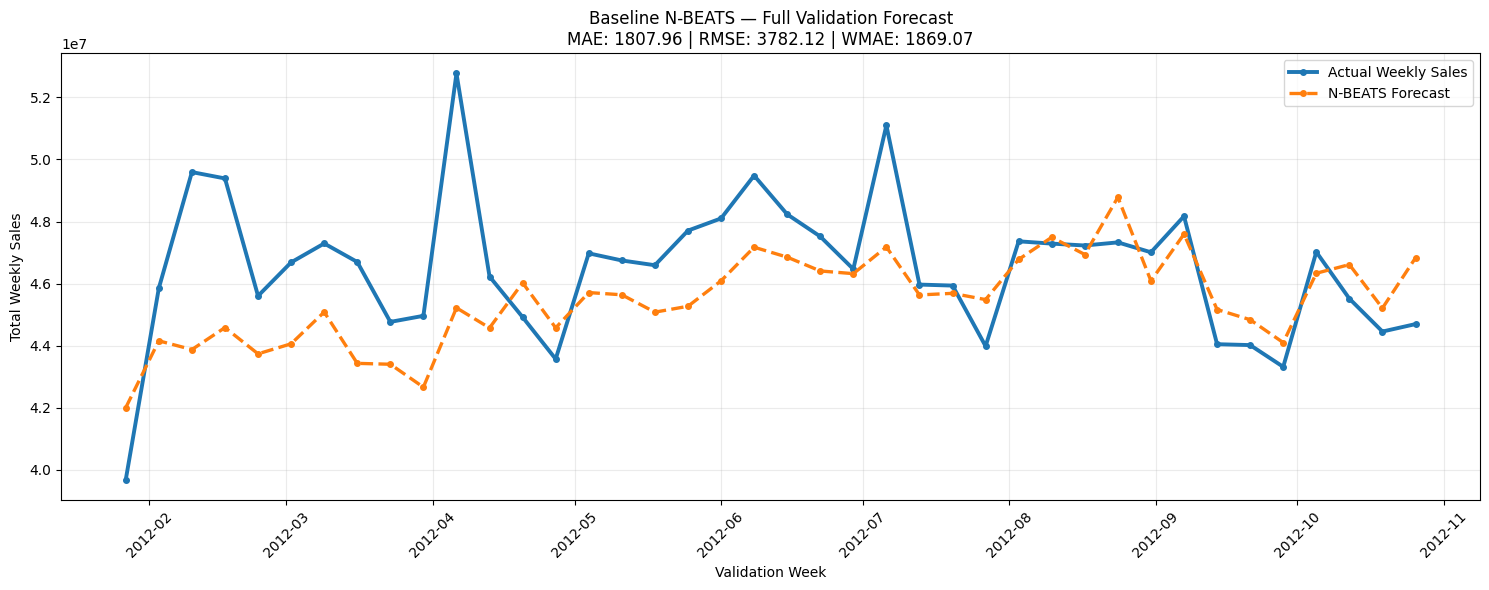

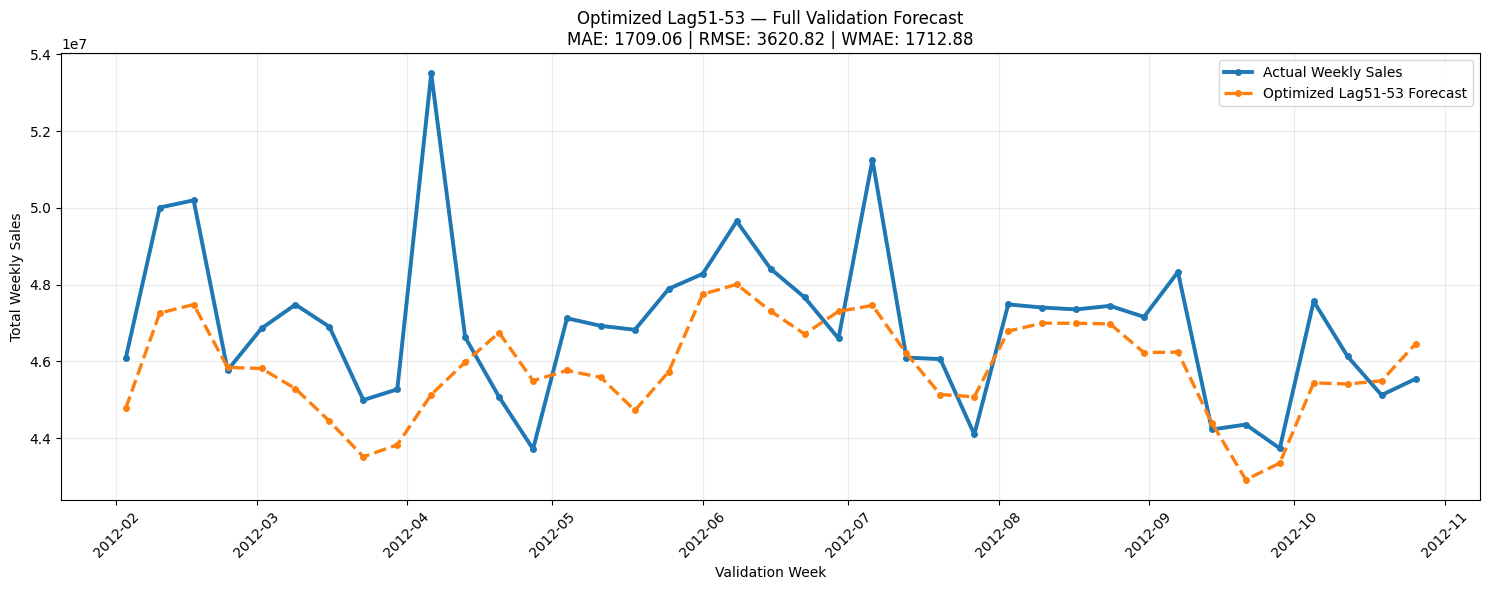

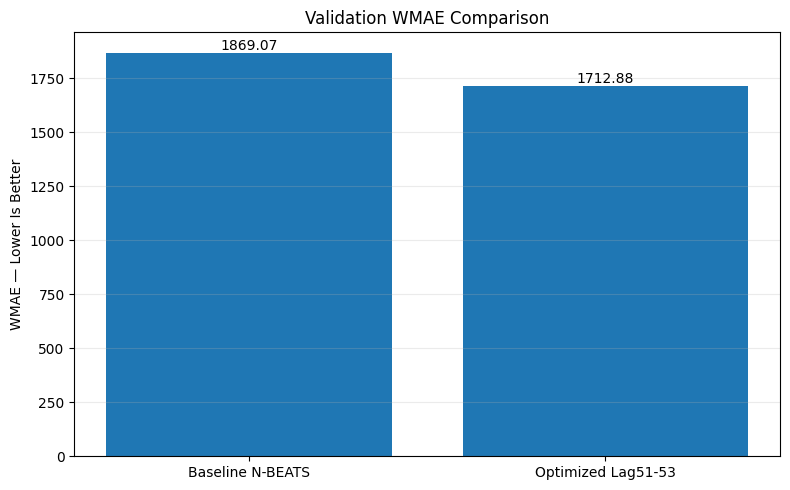

In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error


# ============================================================
# 1. N-BEATS — ზუსტად Notebook-ში შენახული შედეგები
# ============================================================

nbeats_eval = results_detailed[
    ["unique_id", "ds", "y", "IsHoliday", "NBEATS"]
].copy()

nbeats_eval["ds"] = pd.to_datetime(nbeats_eval["ds"])

nbeats_eval = nbeats_eval.dropna(
    subset=["y", "NBEATS", "IsHoliday"]
)

nbeats_weights = np.where(
    nbeats_eval["IsHoliday"].astype(bool),
    5.0,
    1.0
)

nbeats_mae = mean_absolute_error(
    nbeats_eval["y"],
    nbeats_eval["NBEATS"]
)

nbeats_rmse = np.sqrt(
    mean_squared_error(
        nbeats_eval["y"],
        nbeats_eval["NBEATS"]
    )
)

nbeats_wmae = np.sum(
    nbeats_weights *
    np.abs(nbeats_eval["y"] - nbeats_eval["NBEATS"])
) / np.sum(nbeats_weights)


# თითოეული კვირის ყველა Store-Department გაყიდვების ჯამი
nbeats_weekly = (
    nbeats_eval
    .groupby("ds", as_index=False)
    .agg(
        Actual_Sales=("y", "sum"),
        Predicted_Sales=("NBEATS", "sum")
    )
    .sort_values("ds")
)


# ============================================================
# 2. Optimized Lag51-53 — ზუსტად Notebook-ში შენახული შედეგები
# ============================================================

lag_eval = val_df[
    [
        "Store",
        "Dept",
        "Date",
        "Weekly_Sales",
        "IsHoliday",
        "Optimized_Seasonal"
    ]
].copy()

lag_eval["Date"] = pd.to_datetime(lag_eval["Date"])

lag_eval = lag_eval.dropna(
    subset=[
        "Weekly_Sales",
        "Optimized_Seasonal",
        "IsHoliday"
    ]
)

lag_weights = np.where(
    lag_eval["IsHoliday"].astype(bool),
    5.0,
    1.0
)

lag_mae = mean_absolute_error(
    lag_eval["Weekly_Sales"],
    lag_eval["Optimized_Seasonal"]
)

lag_rmse = np.sqrt(
    mean_squared_error(
        lag_eval["Weekly_Sales"],
        lag_eval["Optimized_Seasonal"]
    )
)

lag_wmae = np.sum(
    lag_weights *
    np.abs(
        lag_eval["Weekly_Sales"] -
        lag_eval["Optimized_Seasonal"]
    )
) / np.sum(lag_weights)


# თითოეული კვირის ყველა Store-Department გაყიდვების ჯამი
lag_weekly = (
    lag_eval
    .groupby("Date", as_index=False)
    .agg(
        Actual_Sales=("Weekly_Sales", "sum"),
        Predicted_Sales=("Optimized_Seasonal", "sum")
    )
    .sort_values("Date")
)


# ============================================================
# 3. რეალური მეტრიკების ცხრილი
# ============================================================

metrics = pd.DataFrame({
    "Model": [
        "Baseline N-BEATS",
        "Optimized Lag51-53"
    ],
    "Validation Rows": [
        len(nbeats_eval),
        len(lag_eval)
    ],
    "MAE": [
        nbeats_mae,
        lag_mae
    ],
    "RMSE": [
        nbeats_rmse,
        lag_rmse
    ],
    "WMAE": [
        nbeats_wmae,
        lag_wmae
    ]
})

print("=" * 70)
print("Notebook-ში რეალურად მიღებული Validation შედეგები")
print("=" * 70)

display(metrics.round(2))


# ============================================================
# 4. N-BEATS-ის სრული Validation გრაფიკი
# ============================================================

plt.figure(figsize=(15, 6))

plt.plot(
    nbeats_weekly["ds"],
    nbeats_weekly["Actual_Sales"],
    linewidth=2.8,
    marker="o",
    markersize=4,
    label="Actual Weekly Sales"
)

plt.plot(
    nbeats_weekly["ds"],
    nbeats_weekly["Predicted_Sales"],
    linewidth=2.4,
    linestyle="--",
    marker="o",
    markersize=4,
    label="N-BEATS Forecast"
)

plt.title(
    "Baseline N-BEATS — Full Validation Forecast\n"
    f"MAE: {nbeats_mae:.2f} | "
    f"RMSE: {nbeats_rmse:.2f} | "
    f"WMAE: {nbeats_wmae:.2f}"
)

plt.xlabel("Validation Week")
plt.ylabel("Total Weekly Sales")
plt.legend()
plt.grid(alpha=0.25)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# ============================================================
# 5. Optimized Lag51-53-ის სრული Validation გრაფიკი
# ============================================================

plt.figure(figsize=(15, 6))

plt.plot(
    lag_weekly["Date"],
    lag_weekly["Actual_Sales"],
    linewidth=2.8,
    marker="o",
    markersize=4,
    label="Actual Weekly Sales"
)

plt.plot(
    lag_weekly["Date"],
    lag_weekly["Predicted_Sales"],
    linewidth=2.4,
    linestyle="--",
    marker="o",
    markersize=4,
    label="Optimized Lag51-53 Forecast"
)

plt.title(
    "Optimized Lag51-53 — Full Validation Forecast\n"
    f"MAE: {lag_mae:.2f} | "
    f"RMSE: {lag_rmse:.2f} | "
    f"WMAE: {lag_wmae:.2f}"
)

plt.xlabel("Validation Week")
plt.ylabel("Total Weekly Sales")
plt.legend()
plt.grid(alpha=0.25)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# ============================================================
# 6. WMAE-ის სამართლიანი შედარება
# ============================================================

plt.figure(figsize=(8, 5))

plt.bar(
    metrics["Model"],
    metrics["WMAE"]
)

for index, value in enumerate(metrics["WMAE"]):
    plt.text(
        index,
        value,
        f"{value:.2f}",
        ha="center",
        va="bottom"
    )

plt.title("Validation WMAE Comparison")
plt.ylabel("WMAE — Lower Is Better")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

In [63]:
import mlflow

mlflow.set_experiment("Optimized_Seasonal_Lag")

with mlflow.start_run(run_name="Lag51_52_53_Optimized"):

    # Holiday weights
    mlflow.log_param("holiday_w51", best_holiday["w51"])
    mlflow.log_param("holiday_w52", best_holiday["w52"])
    mlflow.log_param("holiday_w53", best_holiday["w53"])

    # Non-Holiday weights
    mlflow.log_param("normal_w51", best_normal["w51"])
    mlflow.log_param("normal_w52", best_normal["w52"])
    mlflow.log_param("normal_w53", best_normal["w53"])

    # Model info
    mlflow.log_param("lags", "51,52,53")
    mlflow.log_param("fallback", "Series→Dept→Store→Global Mean")

    # Metrics
    mlflow.log_metric("Validation_WMAE", validation_score)

    # Artifacts
    val_df.to_csv("validation_predictions.csv", index=False)
    mlflow.log_artifact("validation_predictions.csv")

    submission.to_csv("optimized_seasonal_submission.csv", index=False)
    mlflow.log_artifact("optimized_seasonal_submission.csv")

print("Lag model successfully logged to MLflow.")

🏃 View run Lag51_52_53_Optimized at: https://dagshub.com/tsarc21/Walmart-Recruiting---Store-Sales-Forecasting.mlflow/#/experiments/14/runs/884d0dd8eb2f45b090b0f3e9c6f9763e
🧪 View experiment at: https://dagshub.com/tsarc21/Walmart-Recruiting---Store-Sales-Forecasting.mlflow/#/experiments/14
Lag model successfully logged to MLflow.


In [64]:
import os
import mlflow
import mlflow.pyfunc
import numpy as np
import pandas as pd


class OptimizedSeasonalLagModel(mlflow.pyfunc.PythonModel):

    def __init__(
        self,
        holiday_weights,
        normal_weights
    ):
        self.holiday_weights = holiday_weights
        self.normal_weights = normal_weights

    def load_context(self, context):
        # Registry-ში მოდელთან ერთად შენახული ისტორიული მონაცემები
        self.history = pd.read_csv(
            context.artifacts["training_history"],
            parse_dates=["Date"]
        )

        self.history = self.history.sort_values(
            ["Store", "Dept", "Date"]
        )

        # fallback მნიშვნელობები
        self.series_mean = (
            self.history
            .groupby(["Store", "Dept"])["Weekly_Sales"]
            .mean()
        )

        self.dept_mean = (
            self.history
            .groupby("Dept")["Weekly_Sales"]
            .mean()
        )

        self.store_mean = (
            self.history
            .groupby("Store")["Weekly_Sales"]
            .mean()
        )

        self.global_mean = self.history["Weekly_Sales"].mean()

    def predict(self, context, model_input, params=None):

        future = model_input.copy()
        future["Date"] = pd.to_datetime(future["Date"])

        required_columns = {
            "Store",
            "Dept",
            "Date",
            "IsHoliday"
        }

        missing_columns = required_columns - set(future.columns)

        if missing_columns:
            raise ValueError(
                f"Missing columns: {sorted(missing_columns)}"
            )

        # Lag 51, 52 და 53-ის დამატება
        for lag in [51, 52, 53]:

            lag_data = self.history[
                ["Store", "Dept", "Date", "Weekly_Sales"]
            ].copy()

            lag_data["Date"] = (
                lag_data["Date"]
                + pd.Timedelta(weeks=lag)
            )

            lag_data = lag_data.rename(
                columns={
                    "Weekly_Sales": f"Lag_{lag}"
                }
            )

            future = future.merge(
                lag_data,
                on=["Store", "Dept", "Date"],
                how="left"
            )

        # fallback: Series → Dept → Store → Global Mean
        series_fallback = future.set_index(
            ["Store", "Dept"]
        ).index.map(self.series_mean)

        dept_fallback = future["Dept"].map(
            self.dept_mean
        )

        store_fallback = future["Store"].map(
            self.store_mean
        )

        fallback = (
            pd.Series(series_fallback, index=future.index)
            .fillna(dept_fallback)
            .fillna(store_fallback)
            .fillna(self.global_mean)
        )

        for column in ["Lag_51", "Lag_52", "Lag_53"]:
            future[column] = future[column].fillna(fallback)

        holiday_mask = (
            future["IsHoliday"]
            .astype(bool)
        )

        prediction = pd.Series(
            index=future.index,
            dtype=float
        )

        prediction.loc[holiday_mask] = (
            self.holiday_weights["w51"]
            * future.loc[holiday_mask, "Lag_51"]
            +
            self.holiday_weights["w52"]
            * future.loc[holiday_mask, "Lag_52"]
            +
            self.holiday_weights["w53"]
            * future.loc[holiday_mask, "Lag_53"]
        )

        prediction.loc[~holiday_mask] = (
            self.normal_weights["w51"]
            * future.loc[~holiday_mask, "Lag_51"]
            +
            self.normal_weights["w52"]
            * future.loc[~holiday_mask, "Lag_52"]
            +
            self.normal_weights["w53"]
            * future.loc[~holiday_mask, "Lag_53"]
        )

        return pd.DataFrame({
            "Weekly_Sales": prediction.clip(lower=0)
        })


# ისტორიული მონაცემების შენახვა მოდელის artifact-ად
training_history = train[
    ["Store", "Dept", "Date", "Weekly_Sales"]
].copy()

training_history["Date"] = pd.to_datetime(
    training_history["Date"]
)

training_history.to_csv(
    "training_history.csv",
    index=False
)

holiday_weights = {
    "w51": float(best_holiday["w51"]),
    "w52": float(best_holiday["w52"]),
    "w53": float(best_holiday["w53"])
}

normal_weights = {
    "w51": float(best_normal["w51"]),
    "w52": float(best_normal["w52"]),
    "w53": float(best_normal["w53"])
}

print("Holiday weights:", holiday_weights)
print("Normal weights:", normal_weights)
print("Training history shape:", training_history.shape)

/usr/local/lib/python3.12/dist-packages/mlflow/pyfunc/utils/data_validation.py:187: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(


Holiday weights: {'w51': 0.1, 'w52': 0.7, 'w53': 0.2}
Normal weights: {'w51': 0.2, 'w52': 0.55, 'w53': 0.25}
Training history shape: (421570, 4)


In [65]:
from mlflow.tracking import MlflowClient

MODEL_NAME = "Walmart_Optimized_Seasonal_Lag"

mlflow.set_experiment(
    "Optimized_Seasonal_Lag"
)

with mlflow.start_run(
    run_name="Lag51_52_53_Registry_Model"
):

    mlflow.log_param(
        "model_type",
        "Optimized Seasonal Lag"
    )

    mlflow.log_param(
        "lags",
        "51,52,53"
    )

    mlflow.log_param(
        "fallback",
        "Series→Dept→Store→Global Mean"
    )

    mlflow.log_metric(
        "Validation_WMAE",
        float(validation_score)
    )

    model_info = mlflow.pyfunc.log_model(
        name="seasonal_lag_model",

        python_model=OptimizedSeasonalLagModel(
            holiday_weights=holiday_weights,
            normal_weights=normal_weights
        ),

        artifacts={
            "training_history": "training_history.csv"
        },

        registered_model_name=MODEL_NAME,

        pip_requirements=[
            f"mlflow=={mlflow.__version__}",
            f"pandas=={pd.__version__}",
            f"numpy=={np.__version__}"
        ]
    )

print("Model registered successfully.")
print("Registered model name:", MODEL_NAME)


# Registry-ში შექმნილი უახლესი version-ის მოძებნა
client = MlflowClient()

versions = client.search_model_versions(
    f"name='{MODEL_NAME}'"
)

latest_version = max(
    versions,
    key=lambda version: int(version.version)
).version

registry_uri = (
    f"models:/{MODEL_NAME}/{latest_version}"
)

print("Registry model URI:", registry_uri)


# მოდელის უშუალოდ Registry-დან ჩამოტვირთვა
loaded_model = mlflow.pyfunc.load_model(
    registry_uri
)

test_example = test[
    ["Store", "Dept", "Date", "IsHoliday"]
].head(10).copy()

registry_predictions = loaded_model.predict(
    test_example
)

display(
    pd.concat(
        [
            test_example.reset_index(drop=True),
            registry_predictions.reset_index(drop=True)
        ],
        axis=1
    )
)

2026/07/25 12:40:51 WARNING mlflow.pyfunc: Passing a Python object as `python_model` causes it to be serialized using CloudPickle, it requires exercising caution as Python object serialization mechanisms may execute arbitrary code during deserialization.Consider using a file path (str or Path) instead. See https://mlflow.org/docs/latest/ml/model/models-from-code/ for details.


Successfully registered model 'Walmart_Optimized_Seasonal_Lag'.
2026/07/25 12:41:01 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: Walmart_Optimized_Seasonal_Lag, version 1
Created version '1' of model 'Walmart_Optimized_Seasonal_Lag'.


🏃 View run Lag51_52_53_Registry_Model at: https://dagshub.com/tsarc21/Walmart-Recruiting---Store-Sales-Forecasting.mlflow/#/experiments/14/runs/0676c7bff4e5417fbeee60378e5afc3a
🧪 View experiment at: https://dagshub.com/tsarc21/Walmart-Recruiting---Store-Sales-Forecasting.mlflow/#/experiments/14
Model registered successfully.
Registered model name: Walmart_Optimized_Seasonal_Lag
Registry model URI: models:/Walmart_Optimized_Seasonal_Lag/1


,Store,Dept,Date,IsHoliday,Weekly_Sales
0,1,1,2012-11-02,False,33570.2160
1,1,1,2012-11-09,False,24060.8940
2,1,1,2012-11-16,False,19332.4980
3,1,1,2012-11-23,True,20977.3560
4,1,1,2012-11-30,False,25800.4160
5,1,1,2012-12-07,False,33796.2345
6,1,1,2012-12-14,False,42859.3965
7,1,1,2012-12-21,False,41847.2460
8,1,1,2012-12-28,True,27360.1350
9,1,1,2013-01-04,False,18328.8295


In [66]:
import mlflow

print(mlflow.get_tracking_uri())

https://dagshub.com/tsarc21/Walmart-Recruiting---Store-Sales-Forecasting.mlflow


In [68]:
import dagshub
print(dagshub.__version__)

0.7.1
